# Aprendizaje automático \- Práctica 1

## Laboratorio de análise intelixente de datos

###### Luis Barba Cepedello, Rubén Pérez Sangiao, Daniel Piqueras Valle



A presente práctica consiste no entrenamento de diversos modelos para a análise de datos. En particular, construiranse e optimizaranse catro modelos de clasificación implementados na librería `scikit-learn`: k\-NN, regresión loxística, árbore de decisión e perceptrón multicapa. O axuste de hiperparámetros levarase a cabo mediante unha validación cruzada anidada con particións externas e internas sobre os datos, co obxectivo de minimizar o sesgo do rendimento. As métricas empregadas para la comparación dos modelos serán a exactitude \(accuracy\), a precisión \(precision\), a exhaustividade \(recall\), pero sobre todo o F1\-score, xa que os datos son moi desbalanceados \(hai moitos máis datos nunha clase que na outra, pero esto xa se comentará\). Para a interpretación dos resultados, incluiranse gráficas comparativas.

Os datos en cuestión cos que se entrenarán os modelos consisten en valores da composición química de viños, en función dos cales os modelos deberán determinar a calidade do viño. Os datos xa contan con esta medida de calidade, polo que o entrenamento será supervisado. A calidade pode variar de 0 a 9, polo que para transformar o problema nun de clasificación considerarase que un viño é de boa calidade se esta ten un valor de 7 ou mais, e neste caso o viño pertencerá a clase 1. Por outro lado, se a calidade é menor de 7, pertencerá á clase 0.

Antes de entrenar os modelos trataranse extensamente os datos, levando a cabo catro filtrados principais: tratamento de duplicados, de valores imposibles, de outliers e de NaN.



## Tratamento dos datos

Comecemos logo polo tratamento dos datos. O primeiro, por suposto, é ler o ficheiro que os contén. Carguemos logo os datos e botemos un primeiro vistazo ao dataframe.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import math

df = pd.read_csv("train.csv")

display(df.head())
print(df.shape)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,6.4,0.310,0.26,13.2,0.046,57.0,205.0,0.99750,3.17,0.41,9.6,5
1,6.3,0.220,0.34,1.2,0.036,32.0,96.0,0.98961,3.06,0.74,NaN,6
2,5.9,0.415,0.13,1.4,0.040,11.0,NaN,0.99220,3.29,0.52,10.5,5
3,6.0,0.330,0.38,9.7,0.040,29.0,124.0,0.99540,3.47,0.48,11.0,6
4,7.8,0.320,0.33,10.4,0.031,47.0,194.0,0.99692,3.07,0.58,9.6,6


(3918, 12)


O dataframe ten 12 columnas \(sen contar a de índices\), das cales a última é a das etiquetas, a calidade. Por tanto, son 11 as variables que teremos que tratar e potencialmente empregar para entrenar os nosos modelos. En canto ás entradas, o dataframe conta con 3918 filas, pero como veremos posteriormente moitas destas serán inservibles ou precisarán de modificación.

Vexamos a continuación as distribucións das variables mediante boxplots.



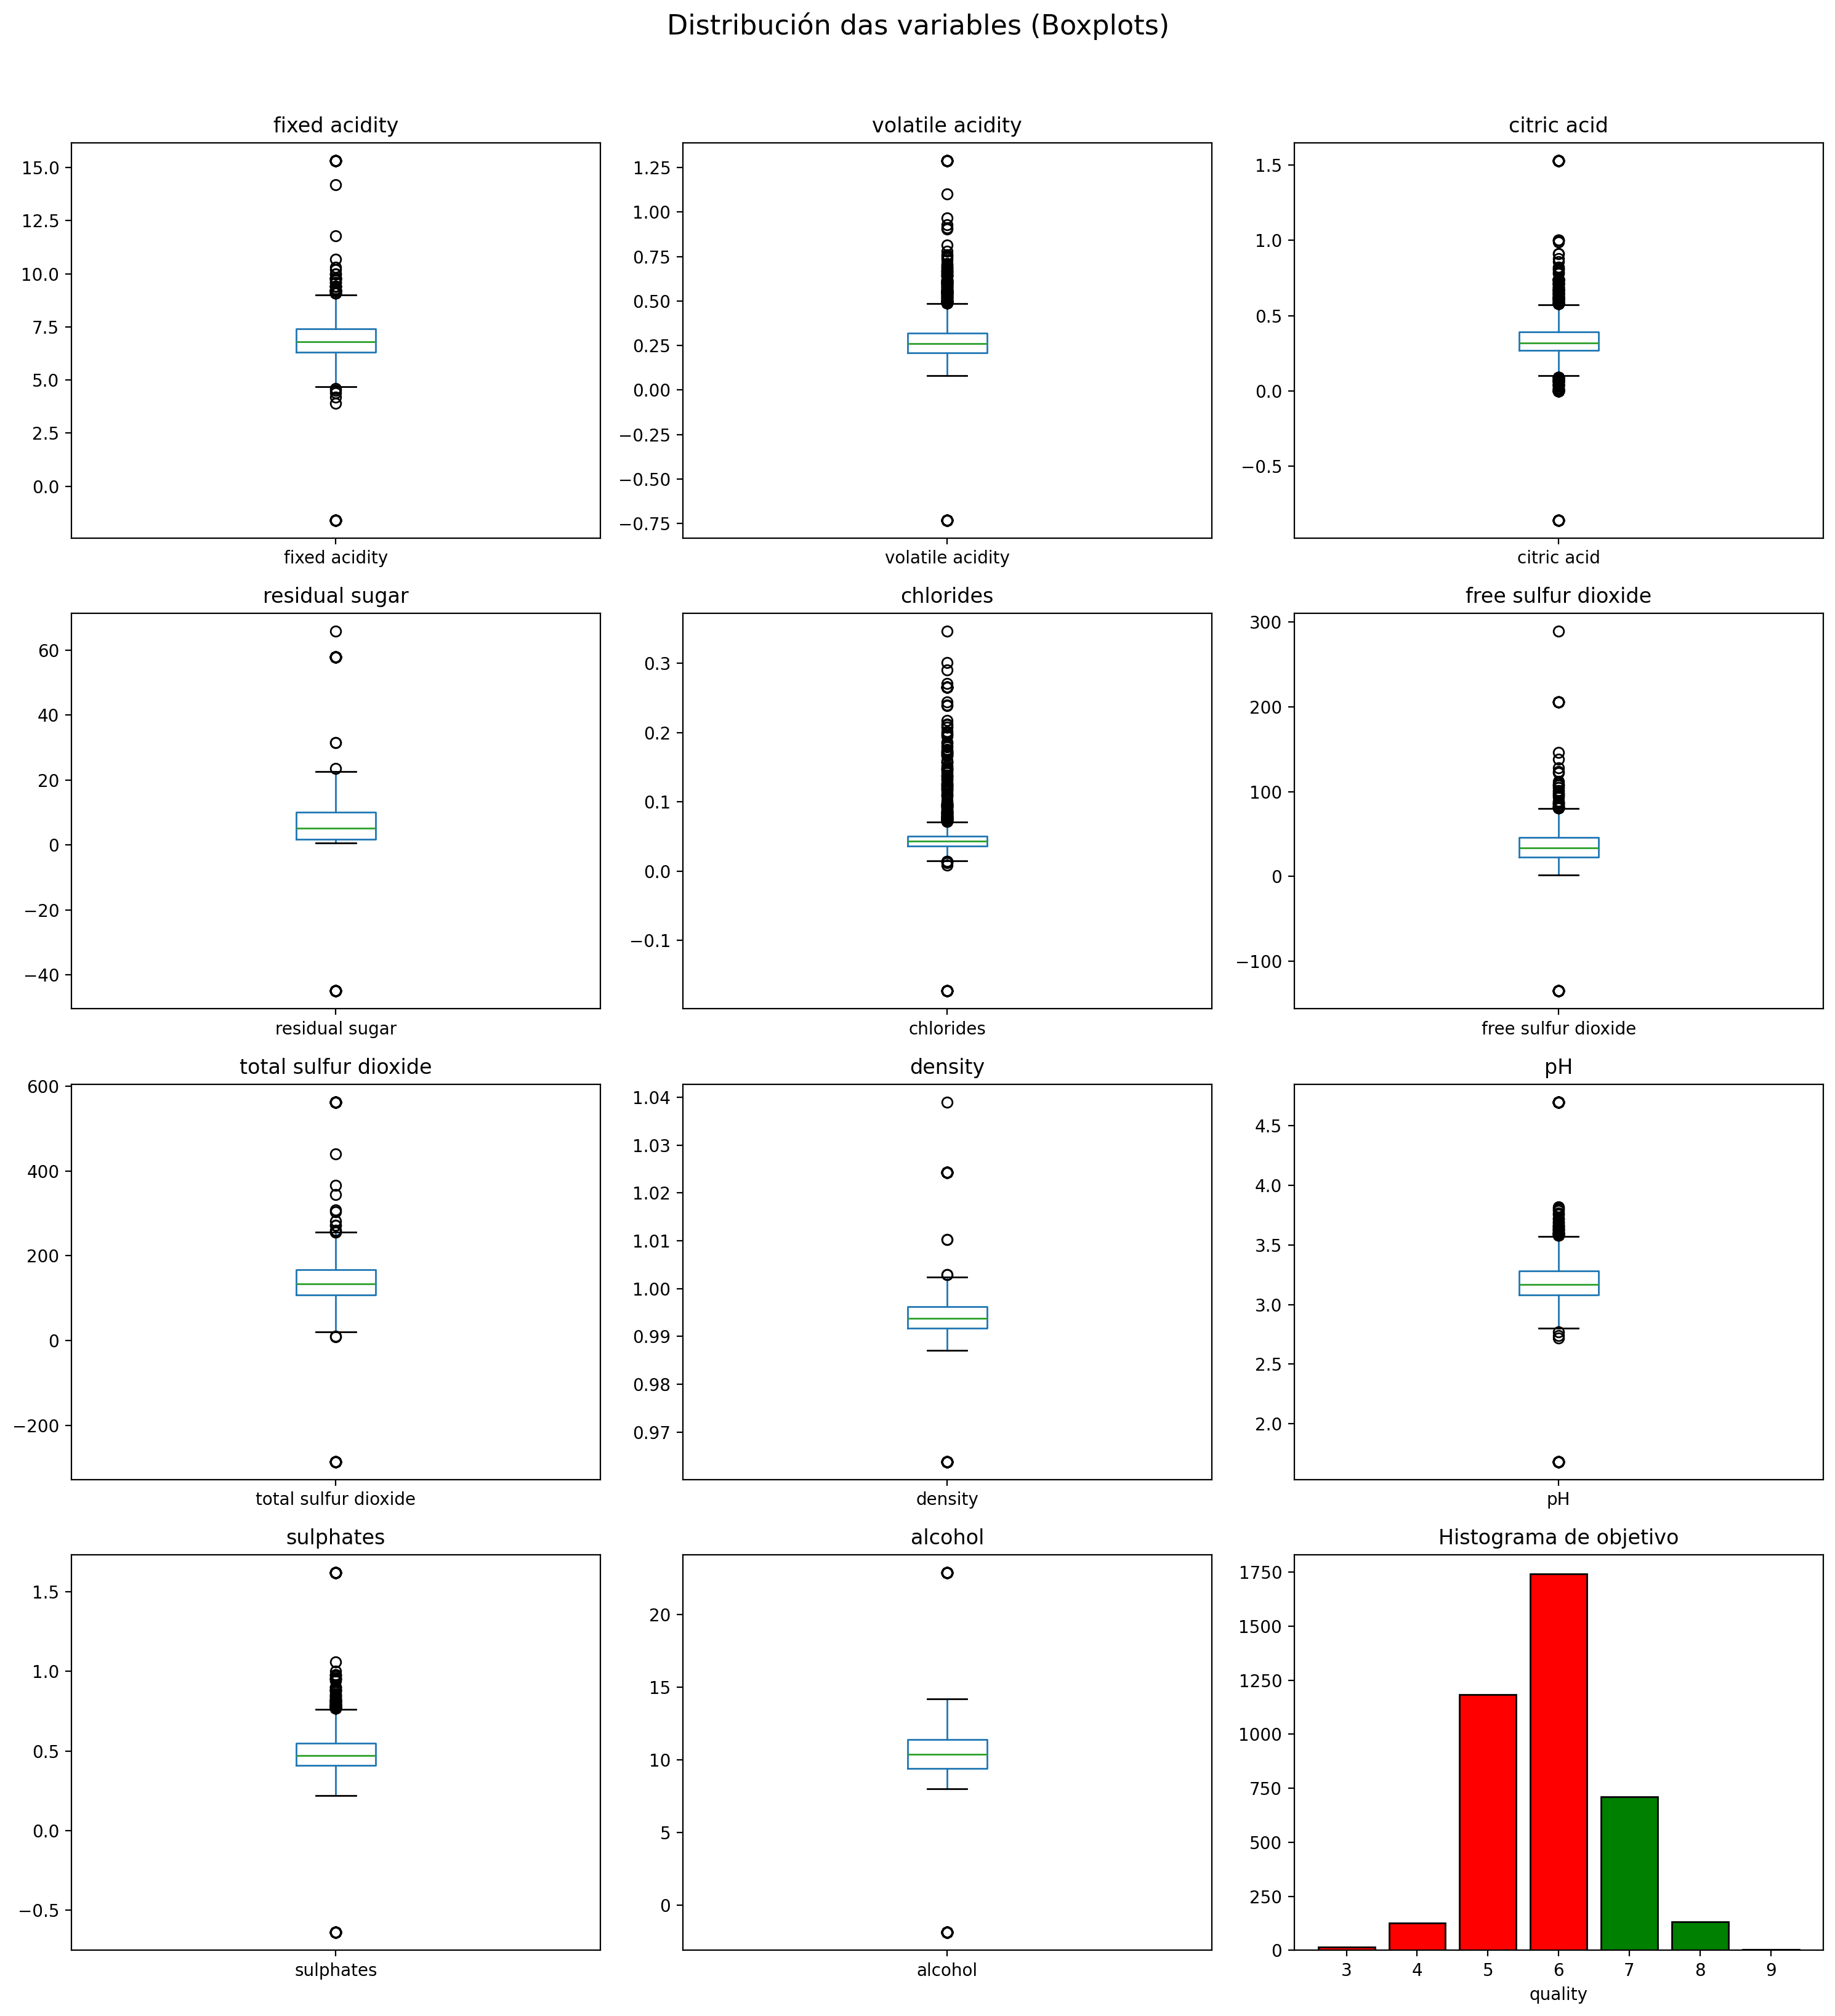

In [4]:
def representar_boxplots(df, nome_etiquetas, titulo):
    # Seleccionamos as variables preditoras
    columnas_variables = df.drop(columns=[nome_etiquetas]).columns
    n_variables = len(columnas_variables)

    # O total de gráficas será o número de variables + 1 (a gráfica de barras final)
    total_graficas = n_variables + 1

    # Calculamos as filas necesarias
    columnas_grid = 3
    filas_grid = math.ceil(total_graficas / columnas_grid)

    # Creamos a figura co tamaño adaptado ao número de filas (para non deixar ocos en branco)
    fig, axes = plt.subplots(nrows=filas_grid, ncols=columnas_grid, figsize=(15, 4 * filas_grid))
    fig.suptitle(titulo, fontsize=16, y=1.02) # y=1.02 axusta un pouco o título cara arriba

    # Aplanamos os eixes (pasamos da matriz 2D a unha lista simple) para iterar fácil
    # Se só hai unha fila, axes xa é 1D, asegurámonos de que funcione sempre
    if isinstance(axes, plt.Axes):
        axes = [axes]
    else:
        axes = axes.flatten()

    # 1. Debuxamos os boxplots iterando por cada recadro
    for i, col in enumerate(columnas_variables):
        df.boxplot(column=col, ax=axes[i], grid=False)
        axes[i].set_title(col)

    # 2. Debuxamos a gráfica de barras xusto no recadro seguinte (índice n_variables)
    ax_bar = axes[n_variables]

    conteos = df[nome_etiquetas].value_counts().sort_index()
    cores = ['green' if valor >= 7 else 'red' for valor in conteos.index]

    ax_bar.bar(conteos.index, conteos.values, color=cores, edgecolor='black')
    ax_bar.set_title('Histograma de objetivo')
    ax_bar.set_xticks(conteos.index)
    ax_bar.set_xlabel(nome_etiquetas)

    # 3. Se sobran recadros baleiros na cuadrícula (por exemplo, quedan ocos na última fila), ocultámolos
    for j in range(total_graficas, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


representar_boxplots(df, 'quality', 'Distribución das variables (Boxplots)')

A primeira vista, vemos que variables como `volatile acidity` ou `sulphates` teñen moitos outliers, mentres que outras como `alcohol` prácticamente non teñen.

No histograma tamén detectamos un serio desbalanceo entre clases, da orde de 75\-80% dos datos son`quality`0. Deberemos ter coidado con que o modelo non realize sempre unha predición negativa aínda que a taxa de acerto sexa elevada.

Pasemos logo ao tratamento. Como xa comentamos na introducción, levaremos a cabo catro procedementos de tratamento sobre os datos. Comezaremos polas filas duplicadas, pois o criterio a seguir con estas sempre será eliminalas, polo que podemos tratalas primeiro sen problemas.



In [5]:
def eliminar_duplicados(df, log=False):

    # Detectamos e contamos as clases de equivalencia, esto é, o número de filas distintas
    conteo_filas = df.value_counts().reset_index(name='cantidade')

    # Obtemos as clases que teñen máis dunha fila (é dicir, que a fila está repetida)
    clases_duplicadas = conteo_filas[conteo_filas['cantidade'] > 1]

    # Eliminamos os duplicados
    df_limpo = df.drop_duplicates()

    if log:
        print("\n--- Clases de equivalencia ---")
        print(
            f"Número de clases de equivalencia con máis dunha fila: {len(clases_duplicadas)}"
        )
        print(
            f"Total de filas a eliminar: {clases_duplicadas['cantidade'].sum() - len(clases_duplicadas)}"
        )
        print(f"Dimensións finais tras eliminar duplicados: {df_limpo.shape}")

    return df_limpo


df_sen_duplicados = eliminar_duplicados(df, log=True)


--- Clases de equivalencia ---
Número de clases de equivalencia con máis dunha fila: 159
Total de filas a eliminar: 178
Dimensións finais tras eliminar duplicados: (3732, 12)


O número de filas eliminadas é 178, polo que o número de filas actual é 3732. Sigamos agora co tratamento dos datos.

Ao representar os boxplots, observamos multitude de valores imposibles. Por exemplo, en `free sulphur dioxide` hai en torno a 20 datos con valor `-135`, seica porque á hora de gardar os datos cometeuse un error e debían ser 135. Ollo, non todos os datos son inválidos simplemente por seren negativos, ou válidos por non selo. De feito, consideraremos que os viños cun `pH` inferior a 2 son datos erróneos \(xa que eso sería imbebible por ser demasiado ácido\). De calquer xeito, a totalidade de valores negativos é inferior a 200, marxinal comparado cos máis de 3700 datos cos que conta o dataframe. En lugar de eliminalos, poremos estos datos a NaN, polo que así poderemos tratalos posteriormente en conxunto aos datos que xa eran NaN.


In [6]:
def eliminar_imposibles(df, log=False):
    # Estas son as condicións que consideramos que non poden cumplir os datos. Se algunha se cumple, hai que poñer a variable a NaN.
    # `density` non está posto que no boxplot anterior viamos que non hai valores negativos.
    limites_inferiores = {
        "fixed acidity": 0,
        "volatile acidity": 0,
        "citric acid": 0,
        "residual sugar": 0,
        "chlorides": 0,
        "free sulfur dioxide": 0,
        "total sulfur dioxide": 0,
        "sulphates": 0,
        "alcohol": 0,
        "pH": 2
    }

    filas_afectadas = set()

    for col, limite in limites_inferiores.items():
        if col in df.columns: #Tiñamos problemas despois ao reducir dimensionalidade
            condicion = df[col] < limite
            filas_afectadas.update(df[condicion].index)
            df.loc[condicion, col] = np.nan
        
    filas_imposibles = len(filas_afectadas)

    if log:
        print("\n--- Filas imposibles ---")
        print(
            f"Total de filas nas que se substituíu algún valor por NaN: {filas_imposibles}"
        )
        print(f"Dimensións finais tras substituír: {df.shape}")

    return df


df_validos = eliminar_imposibles(df_sen_duplicados, True)


--- Filas imposibles ---
Total de filas nas que se substituíu algún valor por NaN: 188
Dimensións finais tras substituír: (3732, 12)


Obsérvese que o número de filas non cambiou, pois simplemente cambiamos os valores inválidos por NaN.

Temos agora conxunto de datos "factible", co que se podería traballar unha vez tratados os NaN. Porén, todavía podemos mellorar a calidade dos datos tratando os outliers. Unha posibilidade é cambiar os valores de outliers por NaN do mesmo xeito que fixemos cos valores imposibles, pero esto sería incorrecto xa que estaríamos fabricando datos ficticios. Imaxinemos que, no caso das vivendas, tivesemos unha con precio e superficie moi altos, dos cales o precio é un outlier por moi pouco e a superficie non o é tamén por pouco. Se substituísemos ese precio pola mediana, por exemplo, estariamos fabricando un dato incoherente, pois sería unha casa con moita superficie pero barata. Así, decidimos que o mellor tratamento que podemos facer con filas que teñan algún outlier é eliminalas.

Nótese que non imos quitar os outliers de `quality`, xa que son as etiquetas.



In [7]:
# Esta función auxiliar identifica os outliers
def detectar_outliers_iqr(df, columnas, factor=1.5):
    if columnas is None:
        columnas = df.select_dtypes(include=['number']).columns

    # Empregaremos unha máscara para guardar nela as condicións de outlier e aplicala ao dataframe
    outliers_mask = pd.DataFrame(False, index=df.index, columns=columnas)

    # Un dato é un outlier se está por debaixo do primeiro cuartil menos o rango intercuartílico (IQR) ou por enriba do terceiro cuartil mais o IQR
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - factor * IQR
        limite_superior = Q3 + factor * IQR

        outliers_mask[col] = (df[col] < limite_inferior) | (df[col] > limite_superior)

    return outliers_mask

In [8]:
def eliminar_outliers(df, columnas=None, log=False):

    #NOTA: Hai que poñer que non se quiten os outliers de quality
    outliers_mask = detectar_outliers_iqr(df, columnas)

    # Empregamos a máscara para obter as filas con al menos un outlier nalgunha variable e as eliminamos
    filas_outliers = outliers_mask.any(axis=1)
    df_limpo = df[~filas_outliers]

    if log:
        print(f"\n--- Outliers ---")
        print(f"Outliers por columna:\n{outliers_mask.sum()}")
        print(f"Filas eliminadas: {filas_outliers.sum()}")
        print(f"Dimensións orixinais: {df.shape}")
        print(f"Dimensións finais: {df_limpo.shape}")

    return df_limpo


# Uso
df_outliers = eliminar_outliers(df_validos, columnas=df_validos.columns.drop('quality'), log=True)


--- Outliers ---
Outliers por columna:
fixed acidity            73
volatile acidity        158
citric acid             227
residual sugar           30
chlorides               166
free sulfur dioxide      46
total sulfur dioxide     34
density                  52
pH                       74
sulphates               101
alcohol                  15
dtype: int64
Filas eliminadas: 808
Dimensións orixinais: (3732, 12)
Dimensións finais: (2924, 12)


Vemos que neste caso sí eliminamos moitas filas. Esto era de esperar, pois basta que cada variable teña uns poucos outliers e que estean repartidos entre distintos datos para que sexan moitos os datos con al menos un outlier nunha das 11 variables. Observemos agora algo interesante se representamos os boxplots:


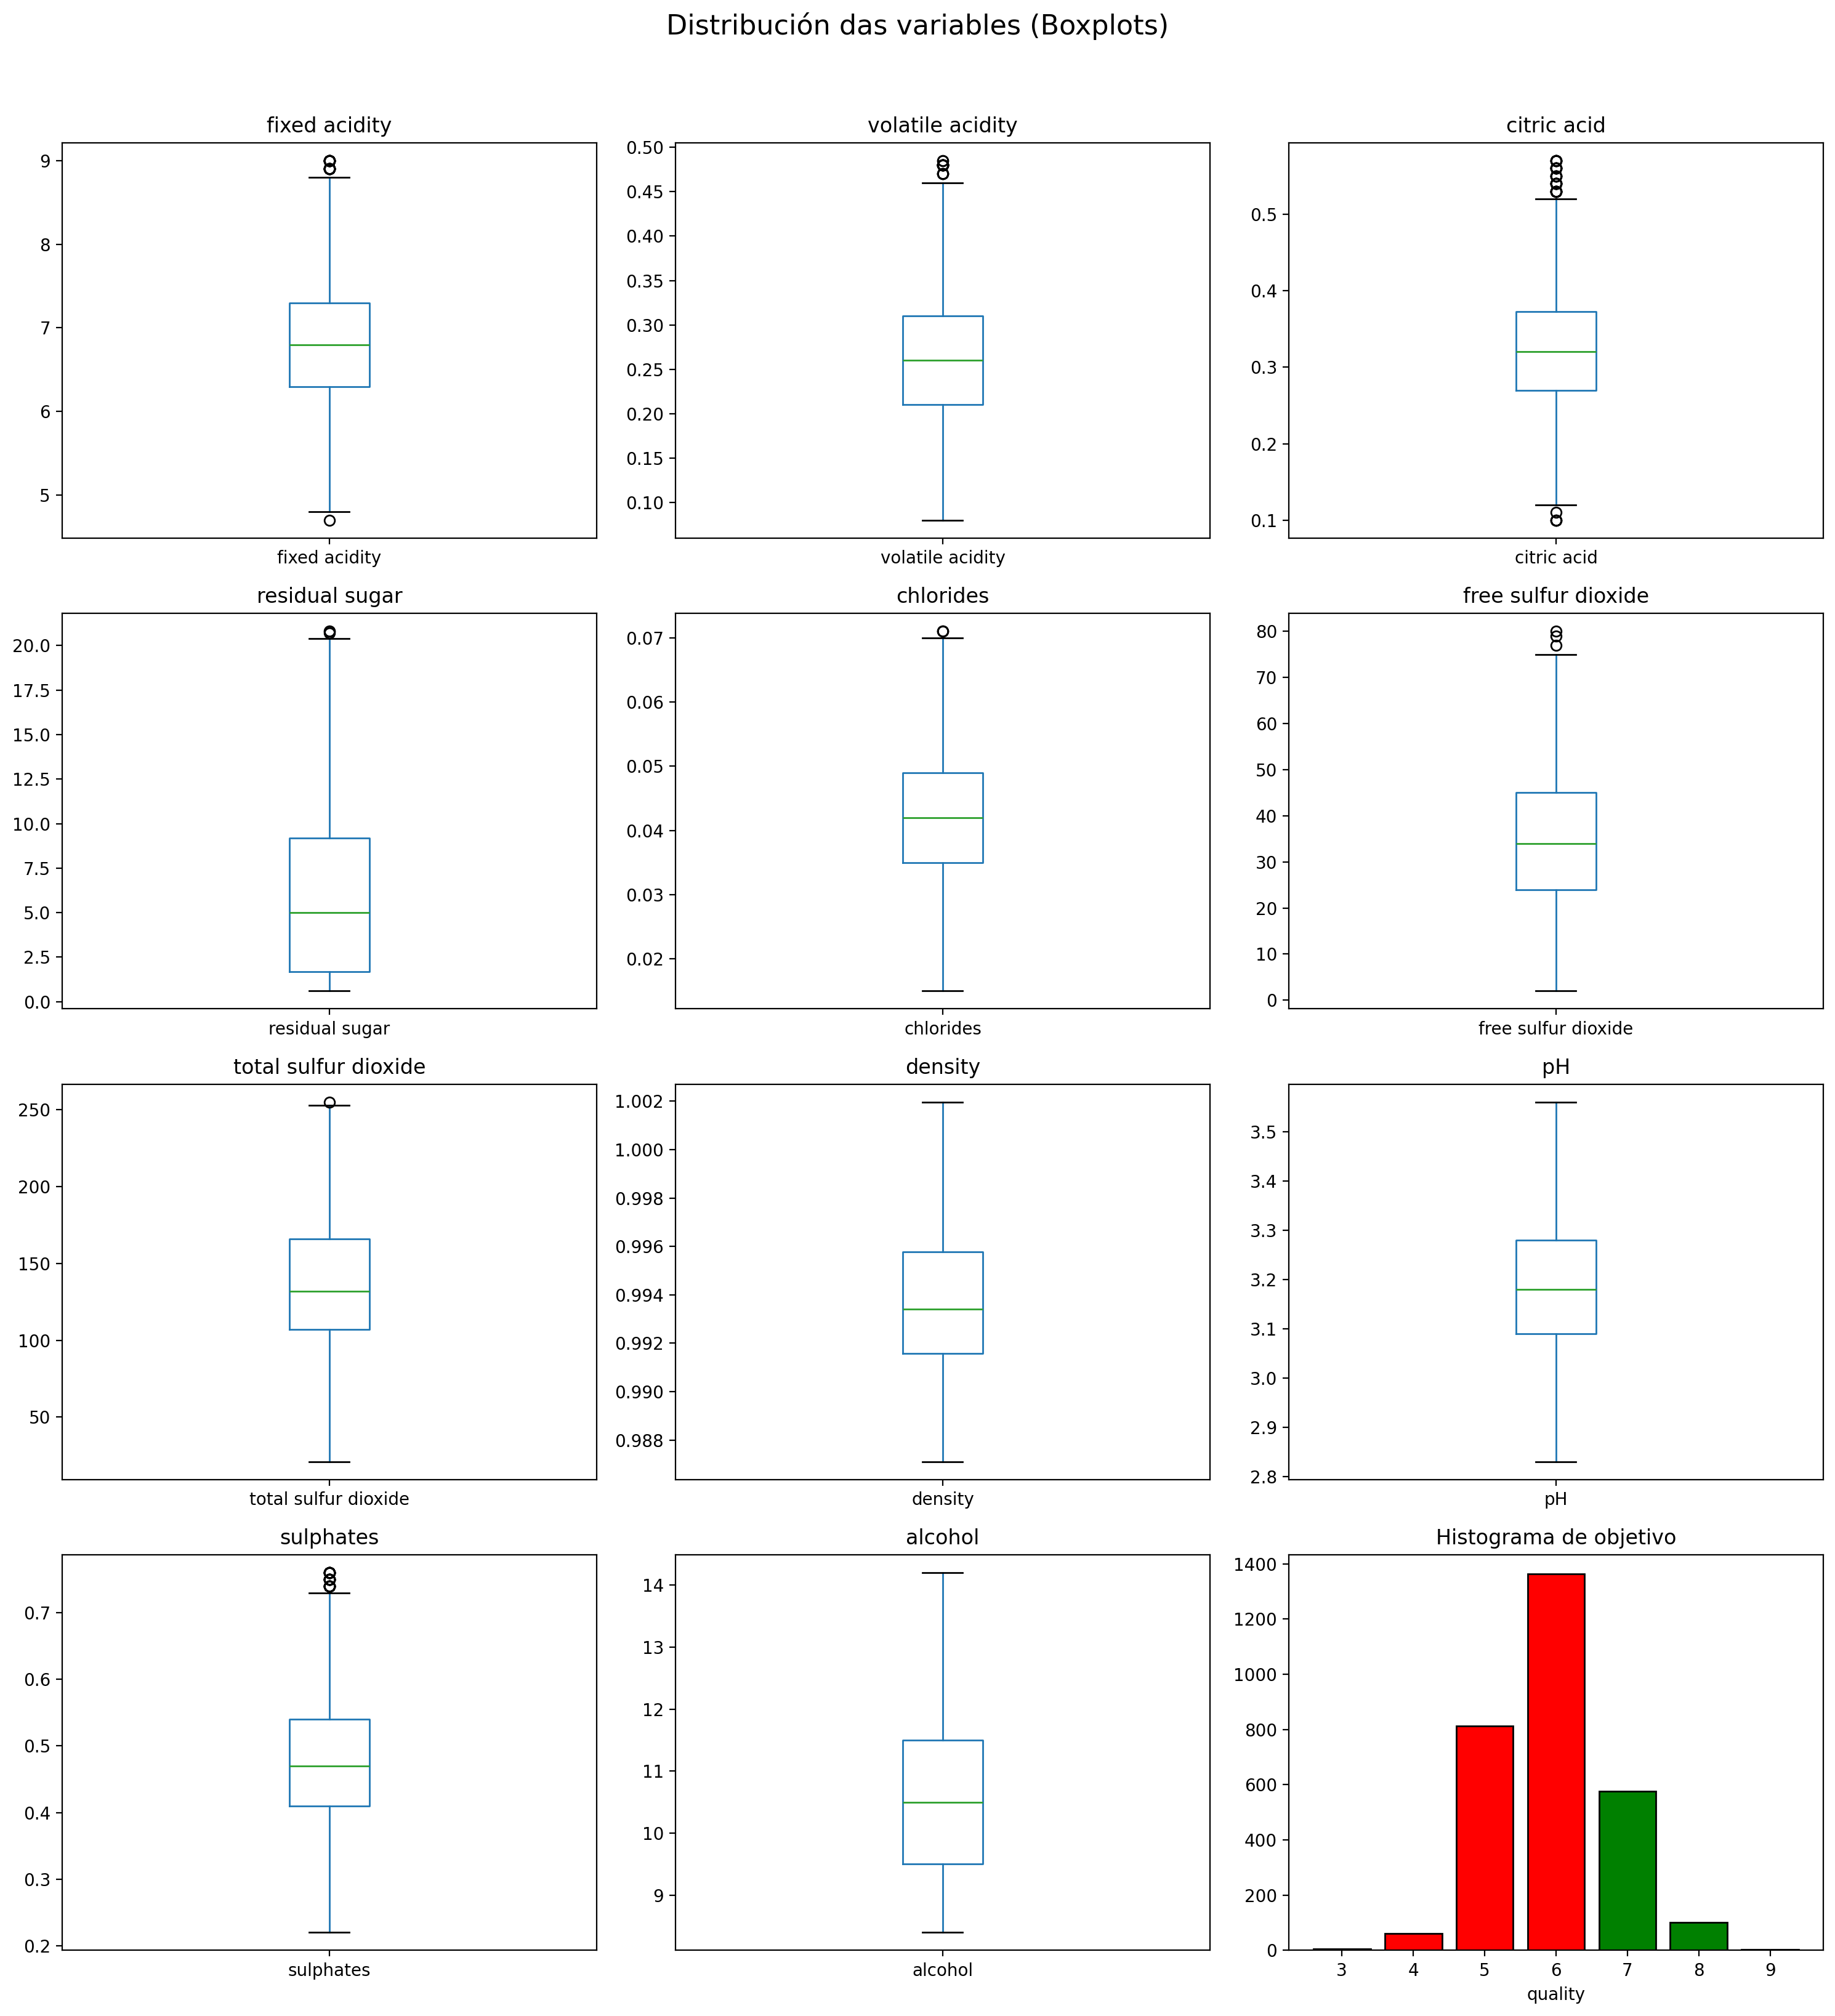

In [9]:
representar_boxplots(df_outliers, 'quality', 'Distribución das variables (Boxplots)')

Hai moitos menos outliers, pero aínda hai algún. Esto é posible? Pois sí, xa que ao reducir o máximo e o mínimo de cada variable recalcúlanse os cuartís e redúcense os bigotes das boxplots, e algúns datos que antes non eran outliers agora poden selo. De calquer xeito, estes datos son moi poucos e moi próximos a non ser outliers, polo que podemos deixalos.

A distribución de `quality` semella ser a mesma que antes.

Para rematar, xa podemos tratar os NaN. Seguiremos esta política: para filas con moitos valores NaN, directamente as trataremos como datos inválidos e las eliminaremos, xa que consideraremos que falta demasiada información e o dato podería perxudicar á distribución. Se pola contra poucas variables titeñen valores NaN, suporemos que hubo un error de medida e os sustituiremos polas medianas das súas respectivas variables. Ademáis, se unha fila ten NaN na etiqueta teremos que borrala tamén, lóxicamente, pois non podemos usar o dato para entrenar con aprendizaxe supervisada.



In [10]:
def eliminar_nan(df, nome_etiquetas, umbral=0.15, log=False, metodo='mediana'):

    # Borramos as filas onde a etiqueta é NaN
    df_limpo = df.dropna(subset=[nome_etiquetas])

    # Calculamos a proporción de NaN por fila
    proporcion_nan = df_limpo.isna().sum(axis=1) / len(df_limpo.columns)

    # Gardamos as filas que teñan máis proporción de NaN que o que permitimos
    filas_moitos_nan = proporcion_nan > umbral

    if log:
        print(f"\n--- Valores NaN (umbral: {umbral*100}%) ---")
        print(f"Filas eliminadas por quality=NaN: {len(df) - len(df_limpo)}")
        print(
            f"Filas eliminadas por ter unha proporción de máis do {umbral*100}% de NaN: {filas_moitos_nan.sum()}"
        )
        print(
            f"Filas con NaN substituídos con mediana: {((proporcion_nan > 0) & (proporcion_nan <= umbral)).sum()}"
        )

    # Eliminamos as filas con máis do umbral de NaN
    df_limpo = df_limpo[~filas_moitos_nan]

    # Substituíos os NaN restantes pola mediana, ou borrar todos
    if metodo == 'mediana':
        df_limpo = df_limpo.fillna(df_limpo.median())
    elif metodo == 'borrar':
        df_limpo = df_limpo.dropna()

    if log:
        print(f"Dimensións orixinais: {df.shape}")
        print(f"Dimensións finais: {df_limpo.shape}")

    return df_limpo


df_nan = eliminar_nan(df_outliers, 'quality', umbral=0.15, log=True)


--- Valores NaN (umbral: 15.0%) ---
Filas eliminadas por quality=NaN: 0
Filas eliminadas por ter unha proporción de máis do 15.0% de NaN: 346
Filas con NaN substituídos con mediana: 1066
Dimensións orixinais: (2924, 12)
Dimensións finais: (2578, 12)


Vemos que 334 filas tiñan demasiados NaN. Así, estas foron eliminadas e noutras 1028 filas substituíronse NaN pola mediana das respectivas variables. Esto daría fin ao preprocesado dos datos, que podemos sintetizar na seguinte función.


In [11]:
def preprocesar_datos(df, nome_etiquetas=None, umbral_exito=0, log=False):
    df_sen_duplicados = eliminar_duplicados(df, log=log)

    df_sen_imposibles = eliminar_imposibles(df_sen_duplicados, log=log)

    cols_analisis = df_sen_imposibles.columns.drop(nome_etiquetas)
    df_sen_outliers = eliminar_outliers(df_sen_imposibles, columnas=cols_analisis, log=log)

    df_final = eliminar_nan(df_sen_outliers, nome_etiquetas, log=log)

    df_final[nome_etiquetas] = (df_final[nome_etiquetas] >= umbral_exito).astype(int)

    return df_final


df_final = preprocesar_datos(df, 'quality', 7, True)


--- Clases de equivalencia ---
Número de clases de equivalencia con máis dunha fila: 159
Total de filas a eliminar: 178
Dimensións finais tras eliminar duplicados: (3732, 12)

--- Filas imposibles ---
Total de filas nas que se substituíu algún valor por NaN: 188
Dimensións finais tras substituír: (3732, 12)

--- Outliers ---
Outliers por columna:
fixed acidity            73
volatile acidity        158
citric acid             227
residual sugar           30
chlorides               166
free sulfur dioxide      46
total sulfur dioxide     34
density                  52
pH                       74
sulphates               101
alcohol                  15
dtype: int64
Filas eliminadas: 808
Dimensións orixinais: (3732, 12)
Dimensións finais: (2924, 12)

--- Valores NaN (umbral: 15.0%) ---
Filas eliminadas por quality=NaN: 0
Filas eliminadas por ter unha proporción de máis do 15.0% de NaN: 346
Filas con NaN substituídos con mediana: 1066
Dimensións orixinais: (2924, 12)
Dimensións finais: (257

## Redución de dimensionalidade e normalización

Tras procesar os datos, xa temos un dataset moito máis estatísticamente robusto sobre o que podemos traballar. Tendo 11 variables independientes, interésanos agora reducir o seu número para escoller as máis importantes. Esto fai que entrenar os modelos sexa moito máis simple e permite eliminar variables que sexan "ruído", esto é, que non aporten apenas á variable de salida.

Faremos uso do módulo `feature_selection` determinar cáles son as variables máis influíntes. Este módulo non crea variables derivadas das orixinais, polo que permite manter o significado físico. Gustaríanos, por exemplo, poder afirmar que a cantidade de alcohol ou presencia de certo composto é o que máis afecta á calidad\).




--- Selección de variables ---
K óptimo para o 95.0% de importancia acumulada: 5
Variables seleccionadas: ['alcohol', 'density', 'chlorides', 'total sulfur dioxide', 'residual sugar']


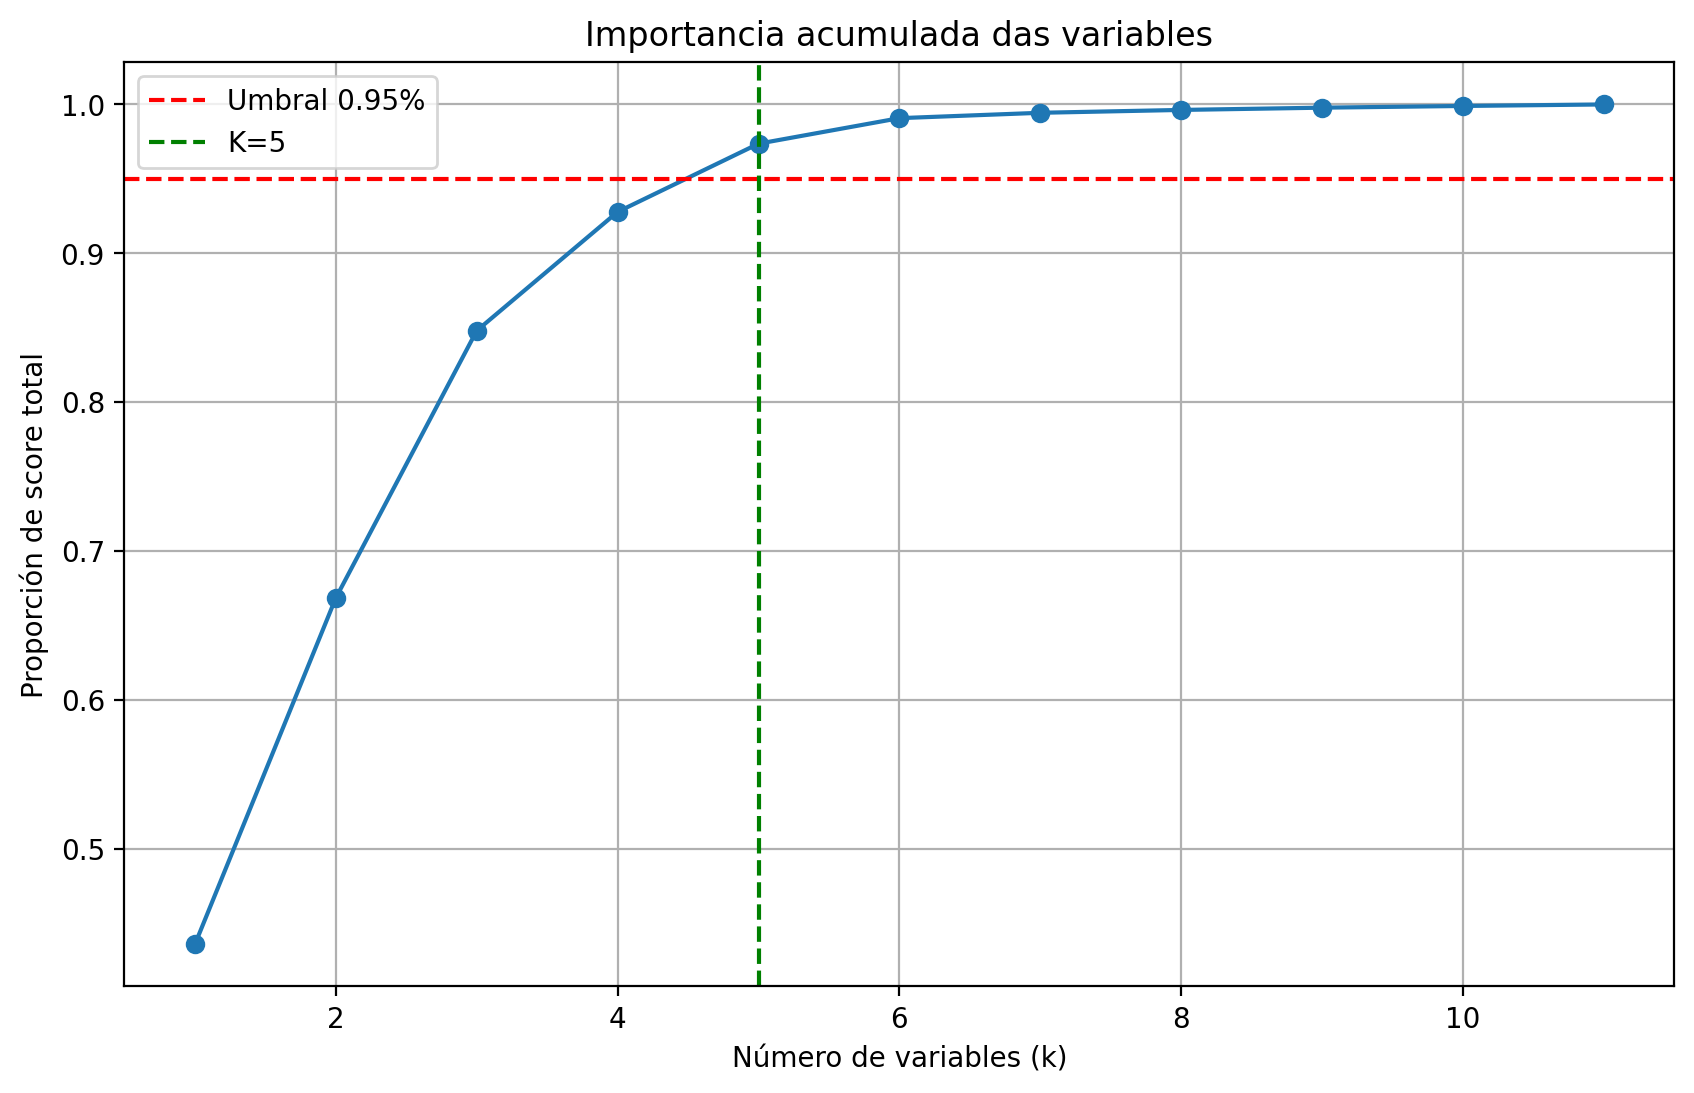

In [12]:
from sklearn.feature_selection import SelectKBest


def reducir_dimensionalidade(df, nome_etiquetas, alpha=0.95, log=False):
    # Separamos as variables preditoras da obxetivo
    X = df.drop(nome_etiquetas, axis=1)
    y = df[nome_etiquetas]

    # Calculamos os scores de todas as variables
    # Empregamos k='all' para no filtrar nada aínda, obtendo só puntuacións
    selector_total = SelectKBest(k='all')
    selector_total.fit(X, y)

    # Obtenemos los scores e os ordenamos de maior a menor
    scores = selector_total.scores_
    indices_ordeados = np.argsort(scores)[::-1]
    scores_ordeados = scores[indices_ordeados]

    # Normalizamos os scores para que sumen 1
    importancia_relativa = scores_ordeados / np.sum(scores)

    # Calculamos a suma acumulada
    acumulado = np.cumsum(importancia_relativa)

    # Buscamos o k para o cal o acumulado supera ao alfa (en tanto por 1)
    # Deste modo teremos o k mínimo para o cal as variables seleccionadas suman máis do alfa% de "importancia"
    # np.argmax devolve o primeiro índice onde a condición é True
    k_optimo = np.argmax(acumulado >= alpha) + 1

    # Aplicamos finalmente SelectKBest con ese k
    selector_final = SelectKBest(k=k_optimo)
    X_reducida = selector_final.fit_transform(X, y)
    selected_cols = X.columns[selector_final.get_support()]
    df_reducido = pd.DataFrame(X_reducida, columns=selected_cols)
    df_reducido[nome_etiquetas] = y.values  # Añadimos el target de nuevo

    if log:
        print(f"\n--- Selección de variables ---")
        print(
            f"K óptimo para o {alpha*100}% de importancia acumulada: {k_optimo}"
        )
        print(
            f"Variables seleccionadas: {list(X.columns[indices_ordeados][:k_optimo])}"
        )

        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(acumulado) + 1), acumulado, marker='o')
        plt.axhline(y=alpha,
                    color='r',
                    linestyle='--',
                    label=f'Umbral {alpha}%')
        plt.axvline(x=k_optimo,
                    color='g',
                    linestyle='--',
                    label=f'K={k_optimo}')
        plt.title('Importancia acumulada das variables')
        plt.xlabel('Número de variables (k)')
        plt.ylabel('Proporción de score total')
        plt.legend()
        plt.grid(True)
        plt.show()

    return df_reducido


df_redimensionado = reducir_dimensionalidade(df_final, 'quality', 0.95, True)

Vemos que con 5 variables \(concretamente `alcohol`, `density`, `chlorides`, `total sulfur dioxide` e `residual sugar`\) sumamos xa máis do 95% de score. Por tanto, estas serán as variables das que faremos uso no entrenamento.

Adicionalmente, a seguinte función axúdanos a visualizar se é posible crear unha fronteira para clasificar os viños en de baixa ou alta calidade según dúas variables. A función crea un gráfico de dispersión de dúas varibles preditoras, coloreando os puntos según a súa clase binaria \(0 o 1\).


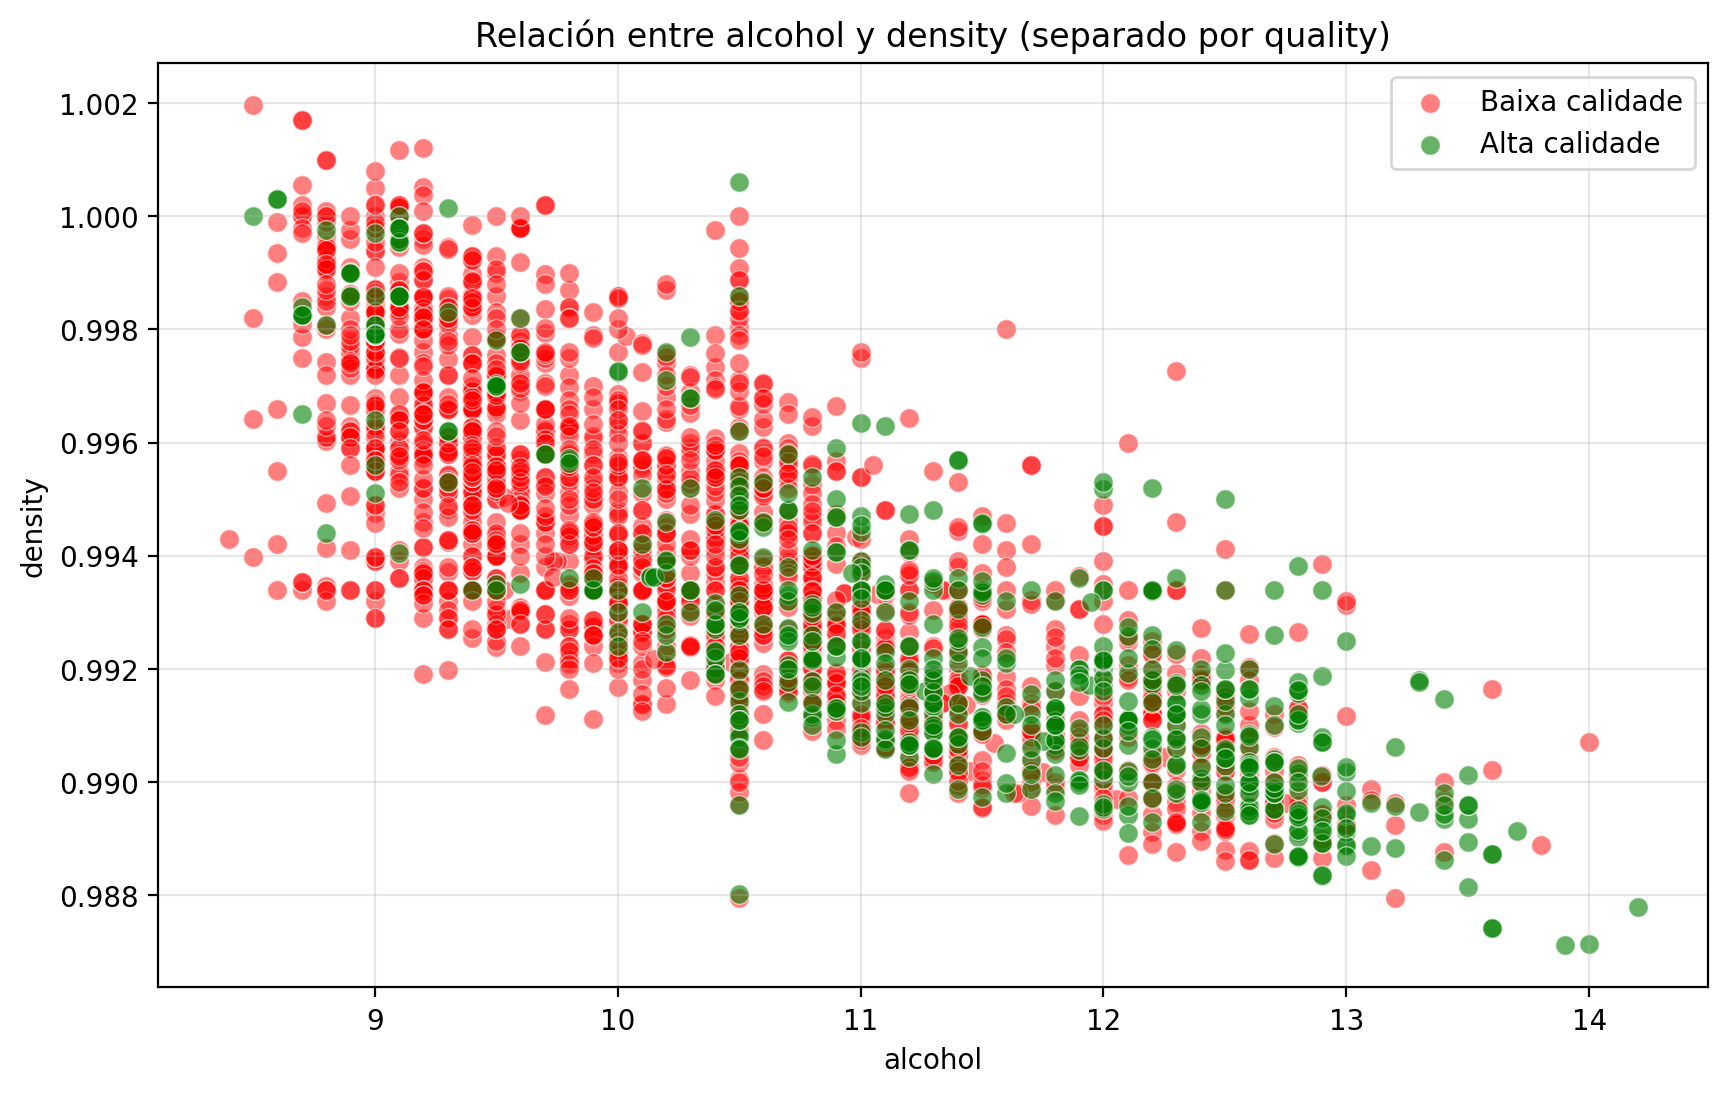

In [13]:
def graficar_dispersion_2d(df, var_x, var_y, variable_clase='quality'):

    plt.figure(figsize=(10, 6))

    # Separamos os datos en dous grupos según a etiqueta
    clase_0 = df[df[variable_clase] == 0]
    clase_1 = df[df[variable_clase] == 1]

    # Graficamos a clase 0
    plt.scatter(clase_0[var_x],
                clase_0[var_y],
                c='red',
                label='Baixa calidade',
                alpha=0.5,
                s=50,
                edgecolors='w',
                linewidth=0.5)

    # Graficamos a clase 1
    plt.scatter(clase_1[var_x],
                clase_1[var_y],
                c='green',
                label='Alta calidade',
                alpha=0.6,
                s=50,
                edgecolors='w',
                linewidth=0.5)

    # Etiquetas e configuración
    plt.xlabel(var_x)
    plt.ylabel(var_y)
    plt.title(
        f'Relación entre {var_x} y {var_y} (separado por {variable_clase})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


graficar_dispersion_2d(df_redimensionado, 'alcohol', 'density')

Vemos que, aínda que hai zonas claramente diferenciadas con viños de baixa e alta calidade, non resulta doado establecer unha fronteira. Como observación interesante, pódese observar unha "cruz" de puntos centrada aproximadamente en \(10.4, 0,9935\). Esto se debe ás filas nas que substituímos NaN pola mediana.

O último que resta agora facer aos datos antes de poder empregalos para entrenar os modelos é normalizalos, o cal podemos levar a cabo de forma moi sencilla con `StandardScaler`.


In [14]:
from sklearn.preprocessing import StandardScaler

def normalizar(df, nome_etiquetas, log=False, devolver_escalador=False):
    x = df.drop(nome_etiquetas, axis=1)
    y = df[nome_etiquetas]

    escalador = StandardScaler()
    x_scaled = escalador.fit_transform(x)

    df_normalizado = pd.DataFrame(x_scaled, columns=x.columns, index=x.index)
    df_normalizado[nome_etiquetas] = y.values
    
    if devolver_escalador==False:
        return df_normalizado
    else:
        return df_normalizado, escalador



df_normalizado = normalizar(df_redimensionado, 'quality')

Para rematar esta sección, podemos sintetizar todo o que levamos feito ata agora na seguinte función, que toma un dataframe de datos crudos e lles aplica todo o filtrado e procesamento que elaboramos ata agora.



--- Clases de equivalencia ---
Número de clases de equivalencia con máis dunha fila: 159
Total de filas a eliminar: 178
Dimensións finais tras eliminar duplicados: (3732, 12)

--- Filas imposibles ---
Total de filas nas que se substituíu algún valor por NaN: 188
Dimensións finais tras substituír: (3732, 12)

--- Outliers ---
Outliers por columna:
fixed acidity            73
volatile acidity        158
citric acid             227
residual sugar           30
chlorides               166
free sulfur dioxide      46
total sulfur dioxide     34
density                  52
pH                       74
sulphates               101
alcohol                  15
dtype: int64
Filas eliminadas: 808
Dimensións orixinais: (3732, 12)
Dimensións finais: (2924, 12)

--- Valores NaN (umbral: 15.0%) ---
Filas eliminadas por quality=NaN: 0
Filas eliminadas por ter unha proporción de máis do 15.0% de NaN: 346
Filas con NaN substituídos con mediana: 1066
Dimensións orixinais: (2924, 12)
Dimensións finais: (257

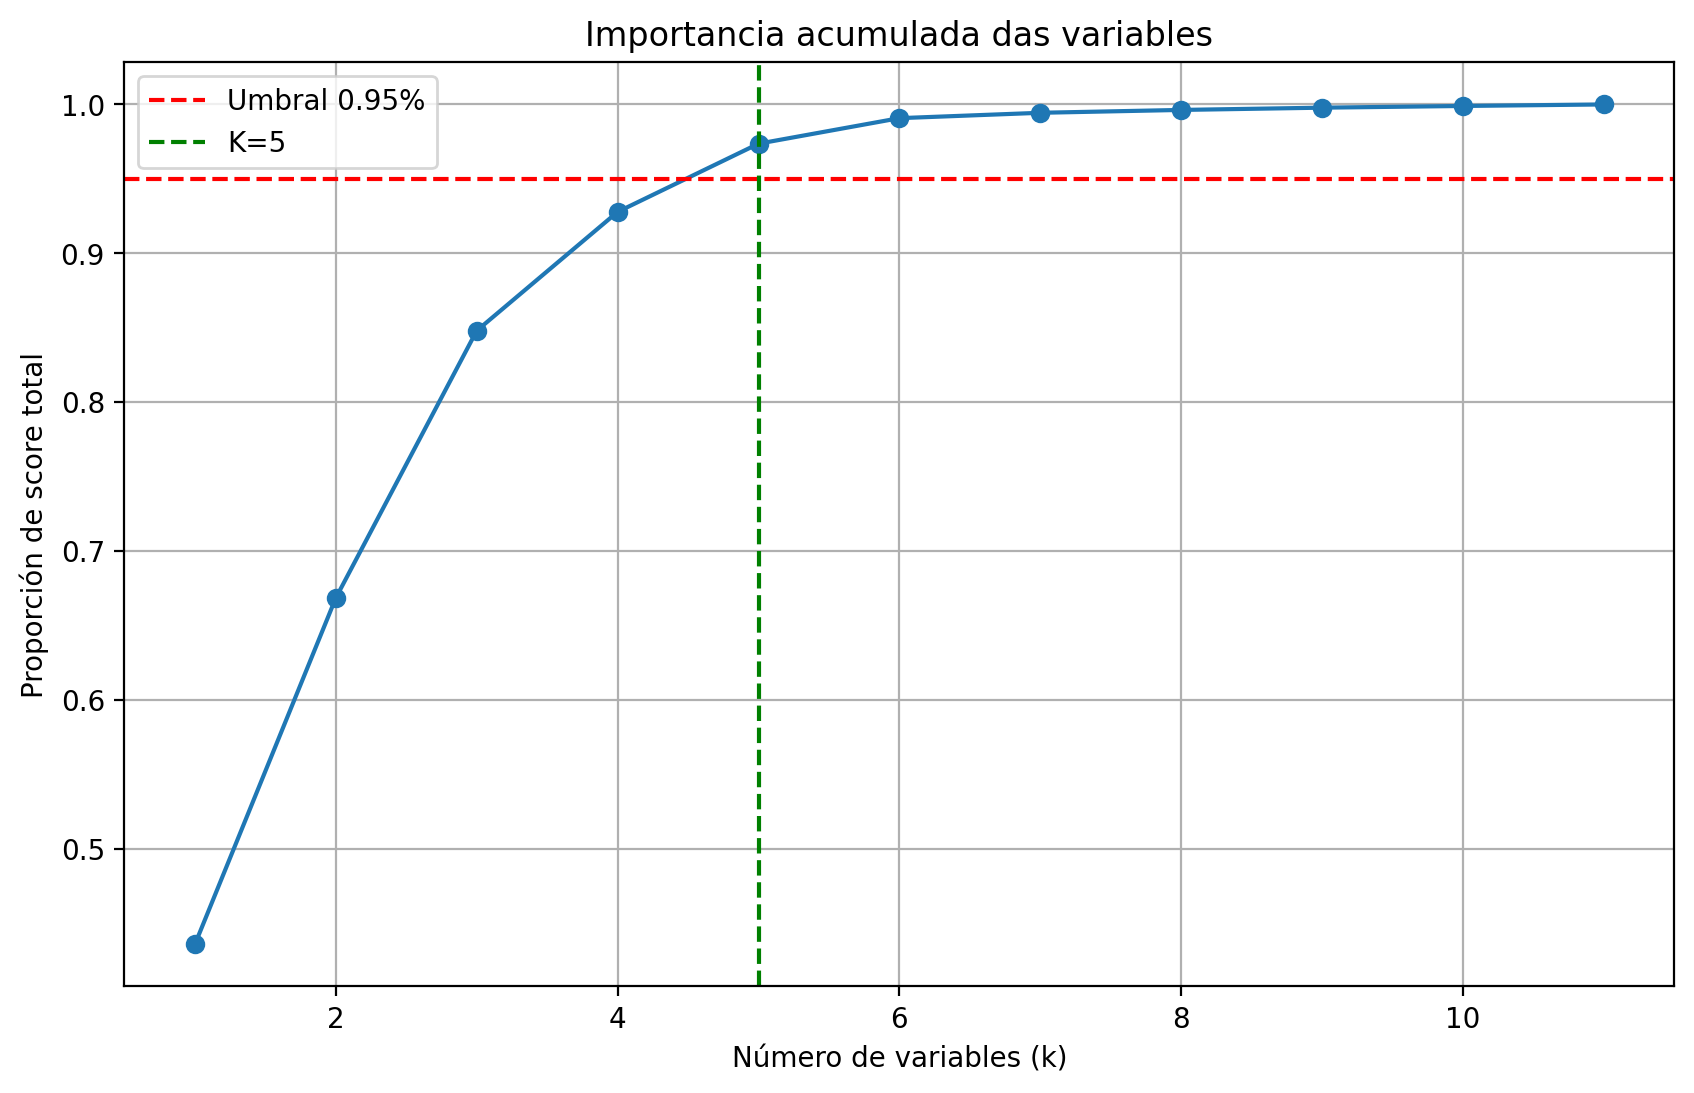

,residual sugar,chlorides,total sulfur dioxide,density,alcohol,quality
0,1.468364,0.386820,1.682856,1.317695,-0.833646,0
1,-1.040975,-0.632731,-1.007206,-1.482058,-0.078855,0
2,-0.999153,-0.224910,-0.094065,-0.563001,-0.078855,0
3,0.736474,-0.224910,-0.316181,0.572514,0.340474,0
4,0.882852,-1.142506,1.411382,1.111883,-0.833646,0


,residual sugar,chlorides,total sulfur dioxide,density,alcohol,quality
2573,0.130050,0.896596,0.152729,-0.016535,0.340474,0
2574,0.422806,0.896596,1.238626,0.785423,-0.749780,0
2575,-0.936419,-0.428820,-0.883808,-0.917849,0.843668,0
2576,0.715562,-0.530776,-0.785090,0.231859,-0.078855,1
2577,-0.999153,1.814192,0.769716,0.217665,-1.001377,0


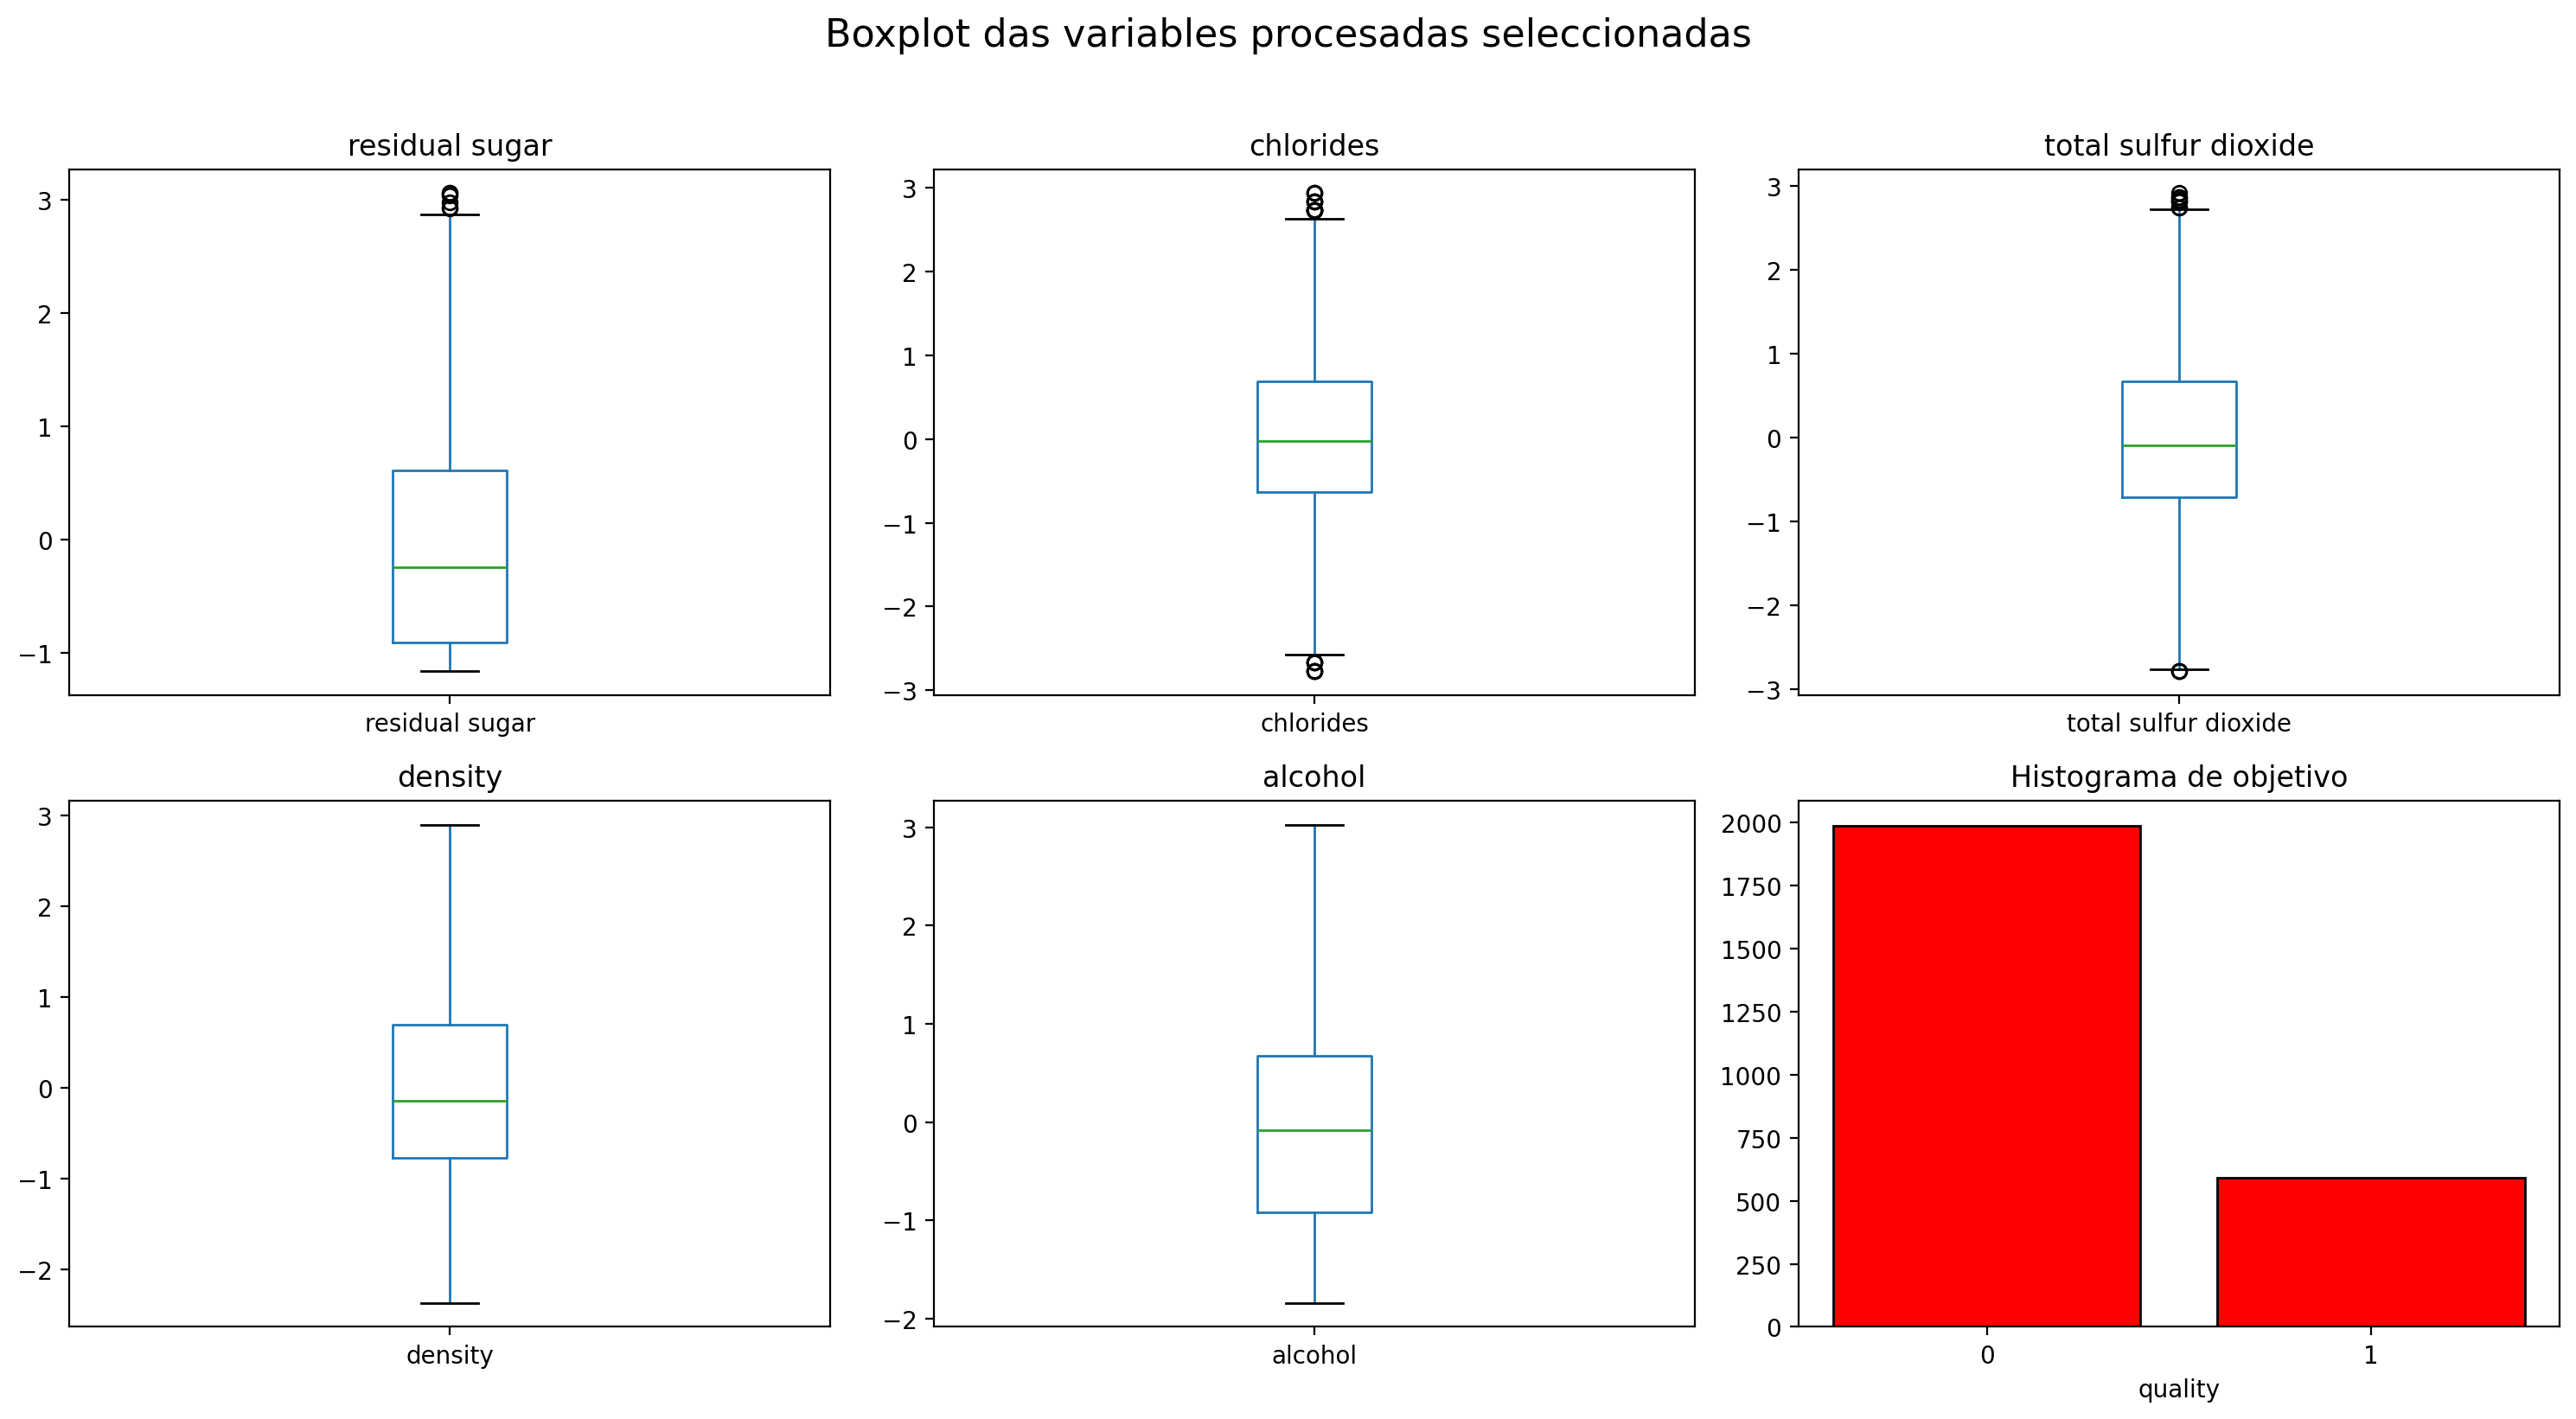

In [15]:
def preparar_conxunto_datos(df,
                            nome_etiquetas='quality',
                            umbral_exito=7,
                            alpha=0.95,
                            nor=True,
                            log=False,
                            box=False):
    df = preprocesar_datos(df, nome_etiquetas, umbral_exito, log)
    df = reducir_dimensionalidade(df, nome_etiquetas, alpha, log)

    if nor:
        df = normalizar(df, nome_etiquetas, log)

    if log:
        display(df.head())
        display(df.tail())

    if box:
        representar_boxplots(df, nome_etiquetas,
                             "Boxplot das variables procesadas seleccionadas")

    return df


df_proba = df.copy()
df_proba_preparado = preparar_conxunto_datos(df=df_proba,
                                             nome_etiquetas='quality',
                                             umbral_exito=7,
                                             alpha=0.95,
                                             nor=True,
                                             log=True,
                                             box=True)

En efecto, aroximadamente o 75%\-80% dos datos son de boa calidade, as clases están moi desbalanceadas. Por eso empregaremos o `f1-score`como métrica para comparar os modelos, en detrimento de outras.


## Validación cruzada

Nesta sección prepararemos os distintos conxuntos de adestramento, test e validación. O obxectivo é ter unha forma de particionar un dataframe en sub\-dataframes que conformen todas as combinacións que empregaremos para adestrar os modelos na validación cruzada anidada.

Comezamos construíndo a función `obter_bloques`, a cal toma un dataframe e devolve `k` bloques de igual tamaño \(se o tamaño do dataframe orixinal non é múltiplo de `k`non hai problema, pois a función crea algúns dos bloques con unha fila máis que os outros\).


In [16]:
from sklearn.model_selection import KFold

def obter_bloques(df, k=6, semente=42, log=False):
    kf = KFold(n_splits=k, shuffle=True, random_state=semente)

    bloques = []
    for _, indices in kf.split(df):
        bloque = df.iloc[indices]
        bloques.append(bloque)

    if log:
        for i, bloque in enumerate(bloques):
            print(f"Bloque {i+1}: {len(bloque)} filas")

        display(bloques[0].head())

    return bloques

# Exemplo
bloques = obter_bloques(df_proba_preparado, k=6, log=True)

Bloque 1: 430 filas
Bloque 2: 430 filas
Bloque 3: 430 filas
Bloque 4: 430 filas
Bloque 5: 429 filas
Bloque 6: 429 filas


,residual sugar,chlorides,total sulfur dioxide,density,alcohol,quality
29,0.485540,-0.734686,0.078691,0.501544,-0.414317,1
30,-0.037239,-2.060102,-0.291501,-0.350092,0.759802,0
43,-0.685485,-0.734686,-0.883808,-1.641740,1.598459,0
44,0.339162,1.304416,0.991831,0.437671,-0.833646,0
51,1.970232,2.120057,0.893113,1.750610,-1.336840,0


Con esto, xa temos o primeiro paso, que era dividir o conxunto de datos en 6 partes iguais. Da a casualidade de que o número de elementos era múltiplo de 6, polo que todos os bloques quedan do mesmo tamaño.

Agora temos que implementar a lóxica da validación cruzada anidada. A seguinte función é unha función auxiliar que recibe unha lista de índices e unha proporción de cantos dos índices deben ir a conxuntos de test. En base a esto, devolve dous vectores de vectores de índices con todas as combinacións de pares train\-test para os índices provistos e a proporción de conxuntos de test proporcionada. Pode resultar algo confuso explicar o que fai a función con linguaxe natural, mais mostarase a salida a continuación é resultará máis claro o seu propósito.


In [17]:
def combinacions_indices(dfs, proporcion_test, log=False):
    n_dfs = len(dfs)
    n_test = math.floor(n_dfs * proporcion_test) # Número de conxuntos de test por cada par test-train

    indices_train = []
    indices_test = []

    # Recórrese a lista de índices dende o final con paso n_test para determinar cales serán os de test en cada par test-train
    for i in range(n_dfs - 1, -1, -n_test):
        bloques_train = []
        bloques_test = []

        # Recórrese a lista dende o principio, e cando esteamos nos índices dos conxuntos de test (bucle externo) os gardamos
        for j in range(n_dfs):
            if (i - n_test < j and j <= i):
                bloques_test.append(dfs[j])
            else:
                bloques_train.append(dfs[j])

        indices_train.append(bloques_train)
        indices_test.append(bloques_test)

    if log:
        print(f"Número de conxuntos de train en cada configuración: {n_dfs - n_test}")
        print(f"Número de conxuntos de test en cada configuración: {n_test}")

    return indices_train, indices_test

# Exemplo
dfs = range(len(bloques))
indices_train, indices_test = combinacions_indices(dfs, 1/3, log=True)
print(indices_train)
print(indices_test)

Número de conxuntos de train en cada configuración: 4
Número de conxuntos de test en cada configuración: 2
[[0, 1, 2, 3], [0, 1, 4, 5], [2, 3, 4, 5]]
[[4, 5], [2, 3], [0, 1]]


A función recibiu o conxunto de índices `[0, 1, 2, 3, 4, 5]` e unha proporción de conxuntos de test de `1/3`. Devolveu os vectores de vectores de índices:

```
[[0, 1, 2, 3], [0, 1, 4, 5], [2, 3, 4, 5]]
[[4, 5], [2, 3], [0, 1]]
```

O cal quere dicir que temos tres pares de conxuntos train\-test:

- No primeiro, adestramos os modelos cos bloques `[0, 1, 2, 3]` e os testeamos cos bloques `[4, 5]`.
- No segundo, adestramos os modelos cos bloques `[0, 1, 4, 5]` e os testeamos cos bloques `[2, 3]`.
- No terceiro, adestramos os modelos cos bloques `[2, 3, 4, 5]` e os testeamos cos bloques `[0, 1]`.



A vantaxe de ter a función anterior programada tal como a temos é que agora podemos determinar os conxuntos requeridos para a validación cruzada anidada mediante dous meros wrappers dela. Para obter as configuracións de conxuntos de adestramento externos e test externos empregamos a seguinte función.


In [18]:
def indices_conxuntos_externos(dfs, proporcion_test=1 / 3, log=False):
    indices_train_externos, indices_test_externos = combinacions_indices(
        dfs, proporcion_test, log)

    if log:
        print(indices_train_externos)
        print(indices_test_externos)

    return indices_train_externos, indices_test_externos


# Exemplo
indices_train_externos, indices_test_externos = indices_conxuntos_externos(
    range(len(bloques)), 1 / 3, log=True)

Número de conxuntos de train en cada configuración: 4
Número de conxuntos de test en cada configuración: 2
[[0, 1, 2, 3], [0, 1, 4, 5], [2, 3, 4, 5]]
[[4, 5], [2, 3], [0, 1]]


E agora, para as configuracións de conxuntos de adestramento internos e validación internos, empregamos a seguinte función, que tomará un conxunto de adestramento externo para obter as configuracións anteriores.


In [19]:
def indices_conxuntos_internos(indices_train_externo,
                               proporcion_test=1 / 4,
                               log=False):
    indices_train_internos, indices_validacion_internos = combinacions_indices(
        indices_train_externo, proporcion_test, log)

    if log:
        print(indices_train_internos)
        print(indices_validacion_internos)

    return indices_train_internos, indices_validacion_internos


# Algúns exemplos
indices_train_internos, indices_validacion_internos = indices_conxuntos_internos(
    indices_train_externos[0], 1 / 4, log=True)
indices_train_internos, indices_validacion_internos = indices_conxuntos_internos(
    indices_train_externos[1], 1 / 4, log=True)
indices_train_internos, indices_validacion_internos = indices_conxuntos_internos(
    indices_train_externos[2], 1 / 4, log=True)

Número de conxuntos de train en cada configuración: 3
Número de conxuntos de test en cada configuración: 1
[[0, 1, 2], [0, 1, 3], [0, 2, 3], [1, 2, 3]]
[[3], [2], [1], [0]]
Número de conxuntos de train en cada configuración: 3
Número de conxuntos de test en cada configuración: 1
[[0, 1, 4], [0, 1, 5], [0, 4, 5], [1, 4, 5]]
[[5], [4], [1], [0]]
Número de conxuntos de train en cada configuración: 3
Número de conxuntos de test en cada configuración: 1
[[2, 3, 4], [2, 3, 5], [2, 4, 5], [3, 4, 5]]
[[5], [4], [3], [2]]


Agora, todo o que resta é unha función que tome os bloques orixinais e un vector de índices e os combine nun dataframe, e xa estaría lista toda a lóxica da validación cruzada anidada. A función en cuestión é `xuntar_bloques`.


In [20]:
def xuntar_bloques(bloques, indices, log=False):

    bloques_seleccionados = [bloques[i] for i in indices]
    df_xunto = pd.concat(bloques_seleccionados, axis=0, ignore_index=True)

    if log:
        print(f"Xuntando bloques: {indices}")
        print(f"Dimensións do dataframe resultante: {df_xunto.shape}")

    return df_xunto


# Algúns exemplos
print("df_train_externo_0:")
df_train_externo_0 = xuntar_bloques(bloques, indices_train_externos[0], True)
print("\ndf_test_externo_0:")
df_test_externo_0 = xuntar_bloques(bloques, indices_test_externos[0], True)
print("\ndf_train_interno_0_0:")
df_train_interno_0_0 = xuntar_bloques(bloques, indices_train_internos[0], True)
print("\ndf_val_interno_0_0:")
df_val_interno_0_0 = xuntar_bloques(bloques, indices_validacion_internos[0],
                                    True)

df_train_externo_0:
Xuntando bloques: [0, 1, 2, 3]
Dimensións do dataframe resultante: (1720, 6)

df_test_externo_0:
Xuntando bloques: [4, 5]
Dimensións do dataframe resultante: (858, 6)

df_train_interno_0_0:
Xuntando bloques: [2, 3, 4]
Dimensións do dataframe resultante: (1289, 6)

df_val_interno_0_0:
Xuntando bloques: [5]
Dimensións do dataframe resultante: (429, 6)


## Funcións dos modelos

Esta será a última sección antes de adestrar todos os modelos. Nela construiremos as 4 funcións que na seguinte sección chamaremos en bucle para cada un dos tipos de modelo \(kNN, regresión loxística, árbores de decisión e perceptrón multicapa\). Estas funcións deben:

- Recibir varios conxuntos de adestramento e validación e **unha** combinación de hiperparámetros.
- Entrenar **un** modelo para **cada par** train\-test.
- Obter unha medida de rendemento de cada modelo entrenado e facer a media desas medidas, que será o que devolvan.

Así, na práctica a cada unha de estas funcións recibirá os conxuntos de adestramento e validación internos derivados dun bloque de adestramento externo, entrenará 4 modelos dun tipo e fará a media dos seus rendementos.

Ademáis das funcións anteriormente descritas, para cada tipo de modelo implementaremos tamén unha función que nos permita graficar os resultados para distintas combinacións de hiperparámetros.

Como observación importante, á hora de evaluar os modelos empregando _accuracy_, en moitos casos obtiñamos valores moi prometedores, do 80% incluso. Porén, hai que considerar que tamén o 80% de los datos pertenecen a una clase \(calidade baixa\). Podería ser que se estivese asignando sempre `quality` 0 a todos os elementos do conxunto de validación. Por eso, despois de ver a disparidade dos datos, decidimos empregar `f1-score`, como xa comentaramos anteriormente.

**NOTA**: As métricas precision, recall e f1 teñen un parámetro "weighted" que ten en conta o desbalanceo entre clases. Vimos que era recomendado empregalo, sobre todo neste caso.

De calquera xeito incluimos en cada función as posibilidades:



In [21]:
from sklearn.metrics import (
    cohen_kappa_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Descomentar o que queiras
#metrica = 'kappa'
#metrica = 'accuracy'
#metrica = 'precision'
#metrica = 'recall'
metrica = 'f1'

#### Funcións dos modelos kNN



In [22]:
from sklearn.neighbors import KNeighborsClassifier

# Función de adestramento
def evaluar_knn(lista_dfs_train, lista_dfs_val, k, nome_etiqueta='quality', metrica='kappa'):
    scores = []

    # Para cada par train-test adestramos un modelo
    for df_train, df_val in zip(lista_dfs_train, lista_dfs_val):

        X_train = df_train.drop(nome_etiqueta, axis=1).values
        y_train = df_train[nome_etiqueta].values

        X_val = df_val.drop(nome_etiqueta, axis=1).values
        y_val = df_val[nome_etiqueta].values

        # Adestramento
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_val)

        # Rendemento dependendo da métrica escollida
        if metrica == 'kappa':
            score = cohen_kappa_score(y_val, y_pred)
        elif metrica == 'accuracy':
            score = accuracy_score(y_val, y_pred)
        elif metrica == 'precision':
            score = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        elif metrica == 'recall':
            score = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        elif metrica == 'f1':
            score = f1_score(y_val, y_pred, average='weighted', zero_division=0)
        else:
            raise ValueError("Métrica non recoñecida.")

        scores.append(score)

    # Promedio dos modelos
    return np.mean(scores)

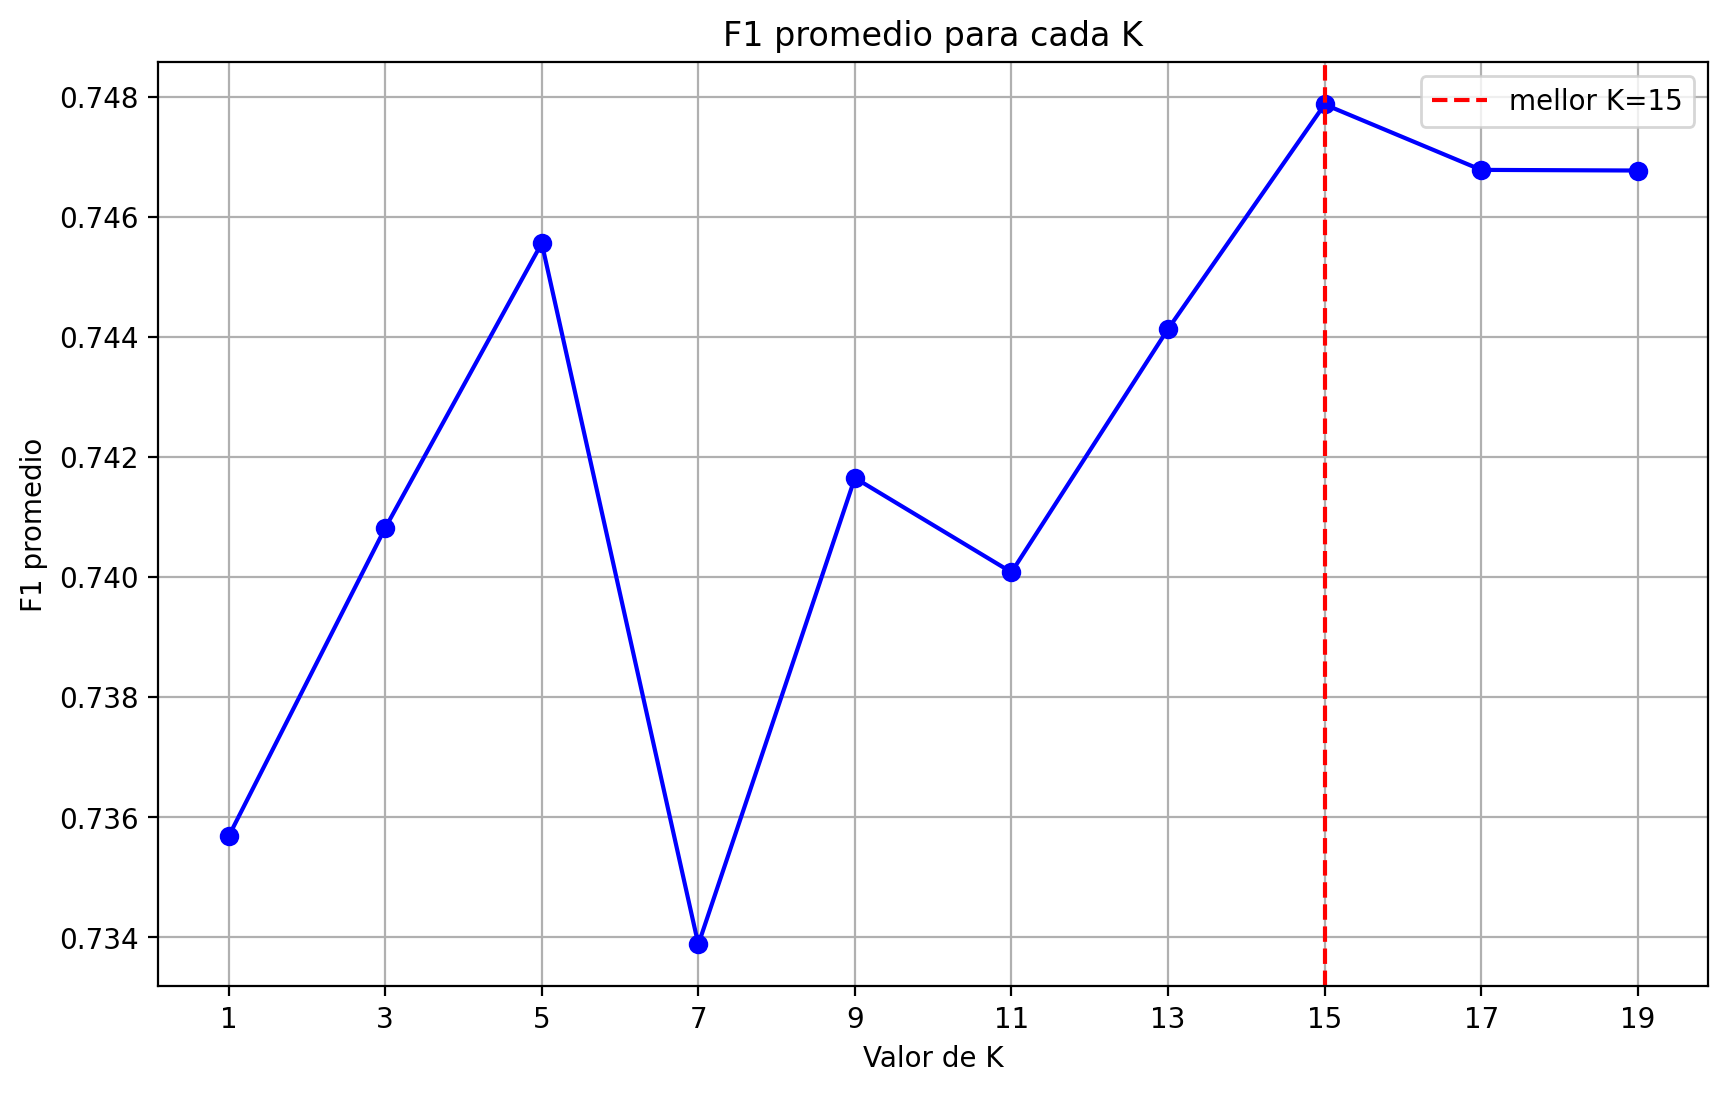

(15, np.float64(0.7478756889916855))

In [23]:
# Función de graficar
def mellor_knn(bloques, indices_train_internos, indices_validacion_internos, k_max, dib=False, metrica='kappa'):

    # Creamos as 4 particions
    lista_dfs_train = []
    lista_dfs_val = []

    for i in range(len(indices_train_internos)):
        lista_dfs_train.append(xuntar_bloques(bloques, indices_train_internos[i]))
        lista_dfs_val.append(xuntar_bloques(bloques, indices_validacion_internos[i]))

    # Valores de k (os escollemos impares para evitar empate)
    k_values = range(1, k_max + 1, 2)
    scores_promedio = [] # Antes kappas_promedio

    mellor_score = -1 # Antes mellor_kappa
    mellor_k = -1

    for k in k_values:
        # Chamamos a evaluar_knn pasándolle a métrica seleccionada
        score_avg = evaluar_knn(lista_dfs_train, lista_dfs_val, k, metrica=metrica)
        scores_promedio.append(score_avg)

        if score_avg > mellor_score:
            mellor_score = score_avg
            mellor_k = k

    # Graficar
    if dib:
        plt.figure(figsize=(10, 6))
        plt.plot(k_values, scores_promedio, marker='o', linestyle='-', color='b')

        # O título e o eixe Y actualízanse automaticamente co nome da métrica
        plt.title(f'{metrica.capitalize()} promedio para cada K')
        plt.xlabel('Valor de K')
        plt.ylabel(f'{metrica.capitalize()} promedio')
        plt.xticks(k_values)
        plt.grid(True)

        # Marcar o mellor punto
        plt.axvline(x=mellor_k, color='r', linestyle='--', label=f'mellor K={mellor_k}')
        plt.legend()

        plt.show()

    return mellor_k, mellor_score

# Exemplo de uso co primeiro conxunto de adestramento externo
mellor_knn(bloques, indices_train_internos, indices_validacion_internos, k_max=20, dib=True, metrica=metrica)

O mellor resultado obtense para `k=15`. Este é un valor alto, e sería razonable considerar empregar `k=5` para reducir considerablemente o número de cálculos, xa que non se perde demasiada calidade na predicción.


#### Funcións dos modelos de regresión loxística

NOTA: No enunciado mándase deixar todos os parámetros fixos excepto _penalty_ e _C_. Os valores de penalty son None, L1, L2 e elástico \(ponderación de L1 e L2\). Porén, o solver por defecto só permite operar con penalty L2 e None, polo que non se pode empregar nin L1 nin a ponderación.

C é un parámetro inverso da restrición \(1/lambda\). Cando C crece, a penalty L2 convértese en None, prácticamente.


In [24]:
from sklearn.linear_model import LogisticRegression

# Función de adestramento
def evaluar_loxistica(lista_dfs_train, lista_dfs_val, penalty, C, nome_etiqueta='quality', metrica='kappa'):
    scores = []

    # O C só se aplica con penalty distinto de None
    if penalty is None:
        modelo = LogisticRegression(penalty=None)
    else:
        modelo = LogisticRegression(penalty=penalty, C=C)

    for df_train, df_val in zip(lista_dfs_train, lista_dfs_val):
        X_train = df_train.drop(nome_etiqueta, axis=1).values
        y_train = df_train[nome_etiqueta].values

        X_val = df_val.drop(nome_etiqueta, axis=1).values
        y_val = df_val[nome_etiqueta].values

        # Adestramento
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_val)

        # Rendemento dependendo da métrica
        if metrica == 'kappa':
            score = cohen_kappa_score(y_val, y_pred)
        elif metrica == 'accuracy':
            score = accuracy_score(y_val, y_pred)
        elif metrica == 'precision':
            score = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        elif metrica == 'recall':
            score = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        elif metrica == 'f1':
            score = f1_score(y_val, y_pred, average='weighted', zero_division=0)
        else:
            raise ValueError("Métrica non recoñecida.")

        scores.append(score)

    return np.mean(scores)

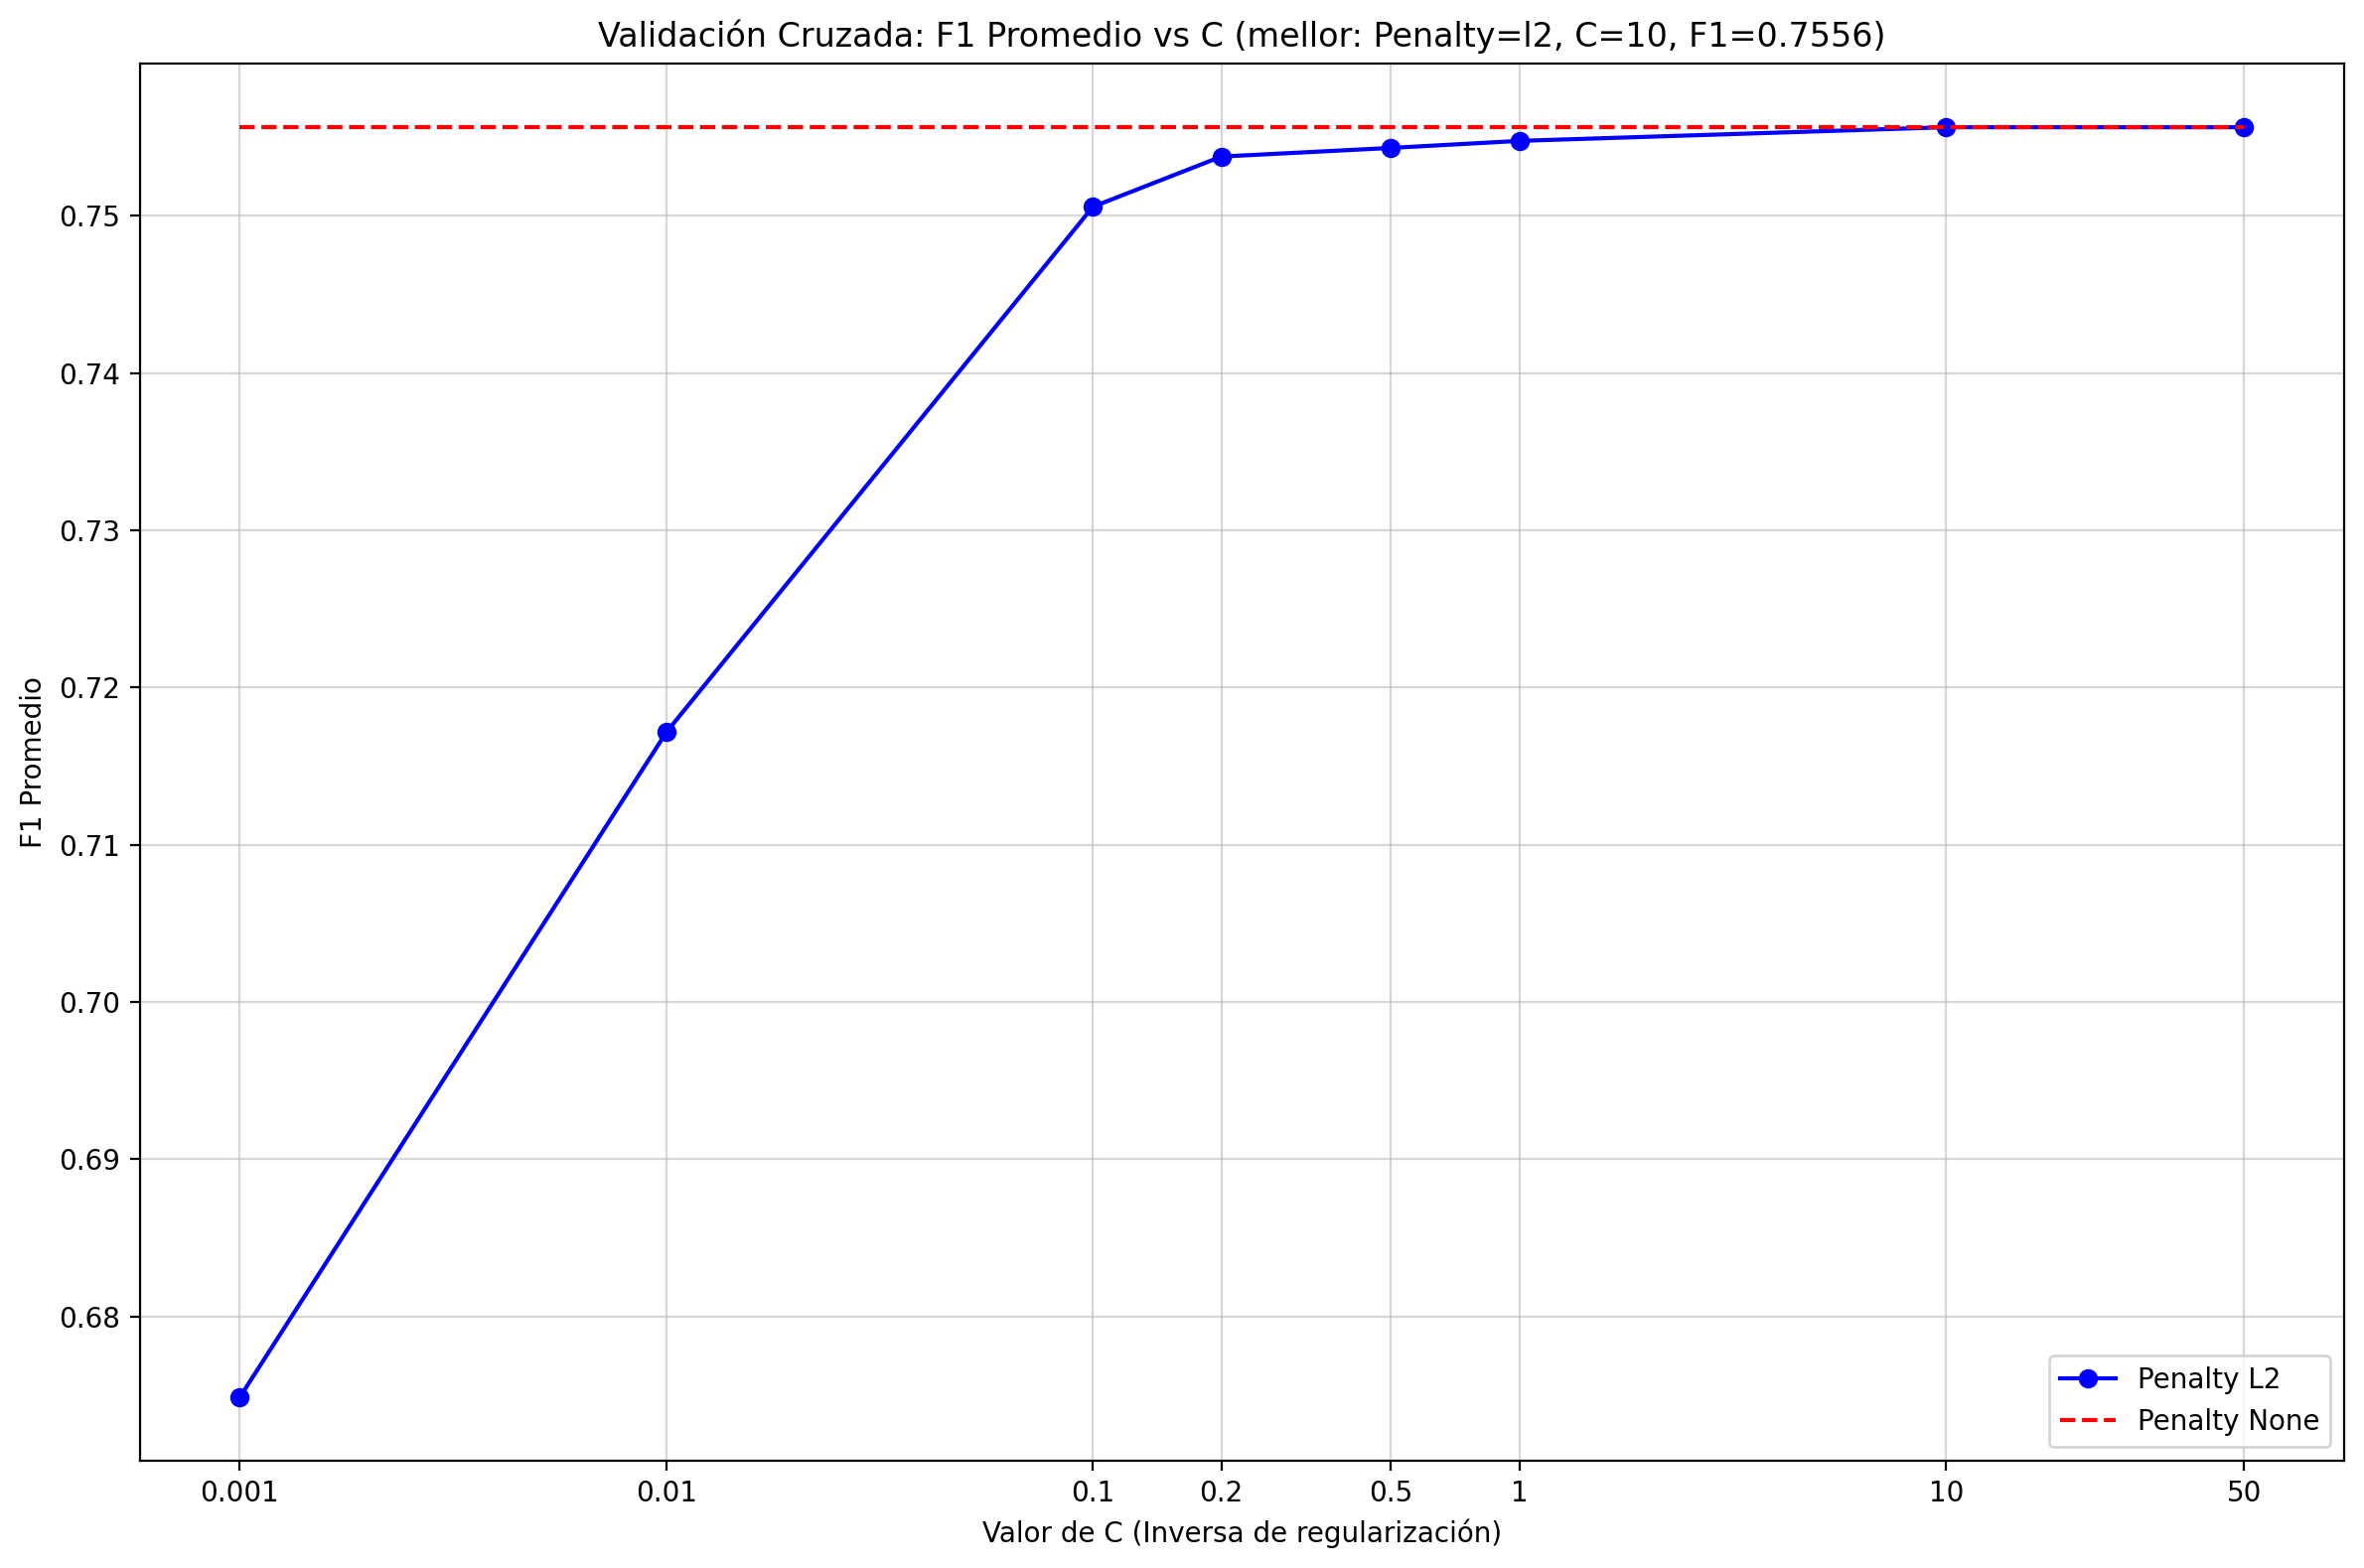

('Penalty=l2, C=10', np.float64(0.7556282551389243))

In [25]:
# Función de graficar
def mellor_loxistica(bloques, indices_train_internos, indices_validacion_internos, C_values, dib=False, metrica='kappa'):

    lista_dfs_train = []
    lista_dfs_val = []

    for i in range(len(indices_train_internos)):
        lista_dfs_train.append(xuntar_bloques(bloques, indices_train_internos[i]))
        lista_dfs_val.append(xuntar_bloques(bloques, indices_validacion_internos[i]))

    resultados = {}

    mellor_score = -1  # Antes mellor_kappa
    mellor_config = "Ningunha"

    penalties = ['l2', None]

    for penalty in penalties:
        pen = str(penalty)
        resultados[pen] = []

        if penalty is None:
            # Calculamos unha vez ignorando C e pasando a métrica
            score_avg = evaluar_loxistica(lista_dfs_train, lista_dfs_val, penalty=None, C=1.0, metrica=metrica)

            # É independente de C asi que queda liña plana
            resultados[pen] = [score_avg] * len(C_values)

            if score_avg > mellor_score:
                mellor_score = score_avg
                mellor_config = "Penalty=None"

        else:
            for c in C_values:
                # Calculamos pasando a métrica
                score_avg = evaluar_loxistica(lista_dfs_train, lista_dfs_val, penalty='l2', C=c, metrica=metrica)
                resultados[pen].append(score_avg)

                if score_avg > mellor_score:
                    mellor_score = score_avg
                    mellor_config = f"Penalty=l2, C={c}"

    if dib:
        plt.figure(figsize=(12, 8))

        # L2 (Línea sólida con puntos)
        plt.plot(C_values, resultados['l2'], marker='o', linestyle='-', color='blue', label='Penalty L2')

        # None (Línea discontinua)
        plt.plot(C_values, resultados['None'], marker='', linestyle='--', color='red', label='Penalty None')

        # Título e eixes dinámicos baseados na métrica
        plt.title(f'Validación Cruzada: {metrica.capitalize()} Promedio vs C (mellor: {mellor_config}, {metrica.capitalize()}={mellor_score:.4f})')
        plt.xlabel('Valor de C (Inversa de regularización)')
        plt.ylabel(f'{metrica.capitalize()} Promedio')

        plt.xscale('log')
        plt.xticks(C_values, C_values)
        plt.minorticks_off()

        plt.grid(True, alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return mellor_config, mellor_score

valores_c = [0.001, 0.01, 0.1, 0.2, 0.5, 1, 10, 50]

mellor_loxistica(bloques, indices_train_internos, indices_validacion_internos, valores_c, dib=True, metrica=metrica)

Canto maior é o C, mellor é o score. Porén, a partires de C = 0.1, a mellora é despreciable. 


#### Funcións dos modelos de árbore de decisión



In [26]:
from sklearn.tree import DecisionTreeClassifier

# Función de adestramnto
def evaluar_cart(lista_dfs_train, lista_dfs_val, depth, leaf, split, semilla=42, nome_etiqueta='quality', metrica='kappa'):
    scores = []

    dt = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=leaf,
        min_samples_split=split,
        random_state=semilla
    )

    for df_train, df_val in zip(lista_dfs_train, lista_dfs_val):
        X_train = df_train.drop(nome_etiqueta, axis=1).values
        y_train = df_train[nome_etiqueta].values

        X_val = df_val.drop(nome_etiqueta, axis=1).values
        y_val = df_val[nome_etiqueta].values

        # Adestramento
        dt.fit(X_train, y_train)

        y_pred = dt.predict(X_val)

        # Rendemento dependendo da métrica
        if metrica == 'kappa':
            score = cohen_kappa_score(y_val, y_pred)
        elif metrica == 'accuracy':
            score = accuracy_score(y_val, y_pred)
        elif metrica == 'precision':
            score = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        elif metrica == 'recall':
            score = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        elif metrica == 'f1':
            score = f1_score(y_val, y_pred, average='weighted', zero_division=0)
        else:
            raise ValueError("Métrica non recoñecida.")

        scores.append(score)

    return np.mean(scores)

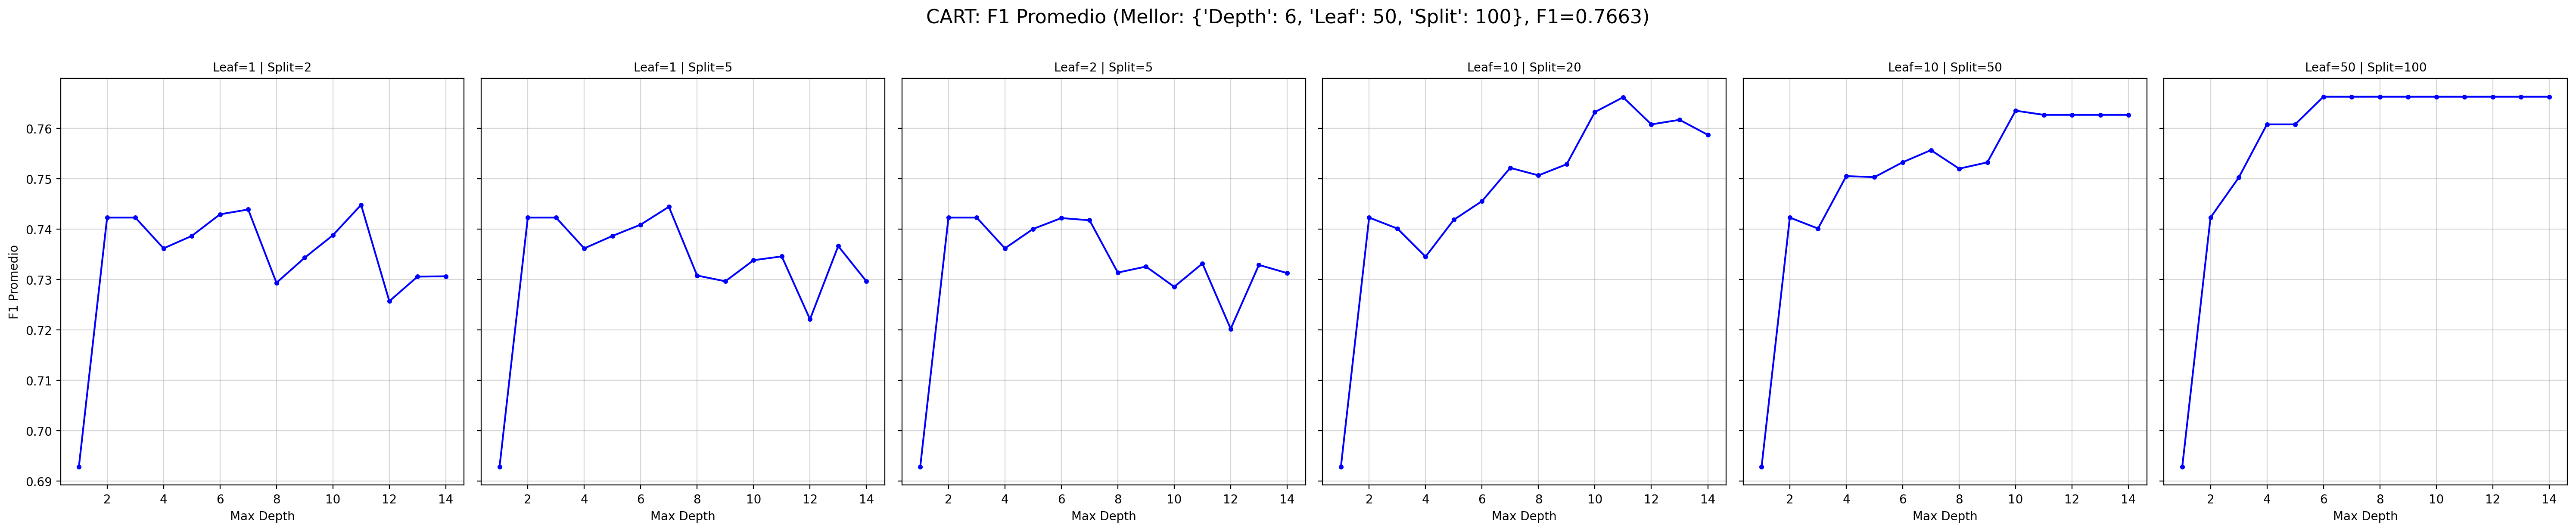

({'Depth': 6, 'Leaf': 50, 'Split': 100}, np.float64(0.7662827201572734))

In [27]:
# Función de graficar
def mellor_cart(bloques, indices_train_internos, indices_validacion_internos, max_depths, pares_leaf_split, dib=False, metrica='kappa'):
    lista_dfs_train = []
    lista_dfs_val = []

    for i in range(len(indices_train_internos)):
        lista_dfs_train.append(xuntar_bloques(bloques, indices_train_internos[i]))
        lista_dfs_val.append(xuntar_bloques(bloques, indices_validacion_internos[i]))

    resultados = {}

    mellor_score = -1 # Antes mellor_kappa
    mellor_config = {}

    for leaf, split in pares_leaf_split:
        resultados[(leaf, split)] = []

        for depth in max_depths:

            # Chamamos á función pasando a métrica
            score_avg = evaluar_cart(lista_dfs_train, lista_dfs_val, depth, leaf, split, metrica=metrica)

            resultados[(leaf, split)].append(score_avg)

            if score_avg > mellor_score:
                mellor_score = score_avg
                mellor_config = {'Depth': depth, 'Leaf': leaf, 'Split': split}

    if dib:
        n_graficos = len(pares_leaf_split)
        fig, axes = plt.subplots(1, n_graficos, figsize=(5 * n_graficos, 6), sharey=True)

        if n_graficos == 1: axes = [axes]
        elif isinstance(axes, np.ndarray): axes = axes.flatten()

        for i, (leaf, split) in enumerate(pares_leaf_split):
            ax = axes[i]
            y_valores = resultados[(leaf, split)]

            ax.plot(max_depths, y_valores, marker='.', linestyle='-', color='blue')

            ax.set_title(f'Leaf={leaf} | Split={split}', fontsize=10)
            ax.grid(True, alpha=0.5)

            # Eixe Y dinámico
            if i == 0: ax.set_ylabel(f'{metrica.capitalize()} Promedio')
            ax.set_xlabel('Max Depth')

        # Título dinámico
        plt.suptitle(f'CART: {metrica.capitalize()} Promedio (Mellor: {mellor_config}, {metrica.capitalize()}={mellor_score:.4f})', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()

    return mellor_config, mellor_score

rango_profundidade = range(1, 15)

# Definimos as parellas (Leaf, Split) que queremos probar
# Así evitamos casos imposibles onde Split < Leaf
pares_parametros = [(1, 2), (1, 5), (2, 5), (10, 20), (10, 50), (50, 100)]

mellor_cart(bloques, indices_train_internos, indices_validacion_internos, rango_profundidade, pares_parametros, dib=True, metrica=metrica)

As gráficas son parecidas no sentido de que seguen un patrón similar, e dan a entender que os parámetros de mínimo número de elementos para ser folla e mínimo número de elementos para dividirse non afectan demasiado.


#### Funcións dos modelos de perceptrón multicapa



In [28]:
from sklearn.neural_network import MLPClassifier

# Función de adestramento
def evaluar_mlp(lista_dfs_train, lista_dfs_val, arq, lr, nome_etiqueta='quality', metrica='kappa'):
    scores = []

    mlp = MLPClassifier(
        hidden_layer_sizes=arq,
        learning_rate_init=lr,
        max_iter=10000,
        random_state=42
    )

    for df_train, df_val in zip(lista_dfs_train, lista_dfs_val):

        X_train = df_train.drop(nome_etiqueta, axis=1).values
        y_train = df_train[nome_etiqueta].values

        X_val = df_val.drop(nome_etiqueta, axis=1).values
        y_val = df_val[nome_etiqueta].values

        # Adestramento
        mlp.fit(X_train, y_train)
        y_pred = mlp.predict(X_val)

        # Rendemento dependendo da métrica
        if metrica == 'kappa':
            score = cohen_kappa_score(y_val, y_pred)
        elif metrica == 'accuracy':
            score = accuracy_score(y_val, y_pred)
        elif metrica == 'precision':
            score = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        elif metrica == 'recall':
            score = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        elif metrica == 'f1':
            score = f1_score(y_val, y_pred, average='weighted', zero_division=0)
        else:
            raise ValueError("Métrica non recoñecida.")

        scores.append(score)

    return np.mean(scores)

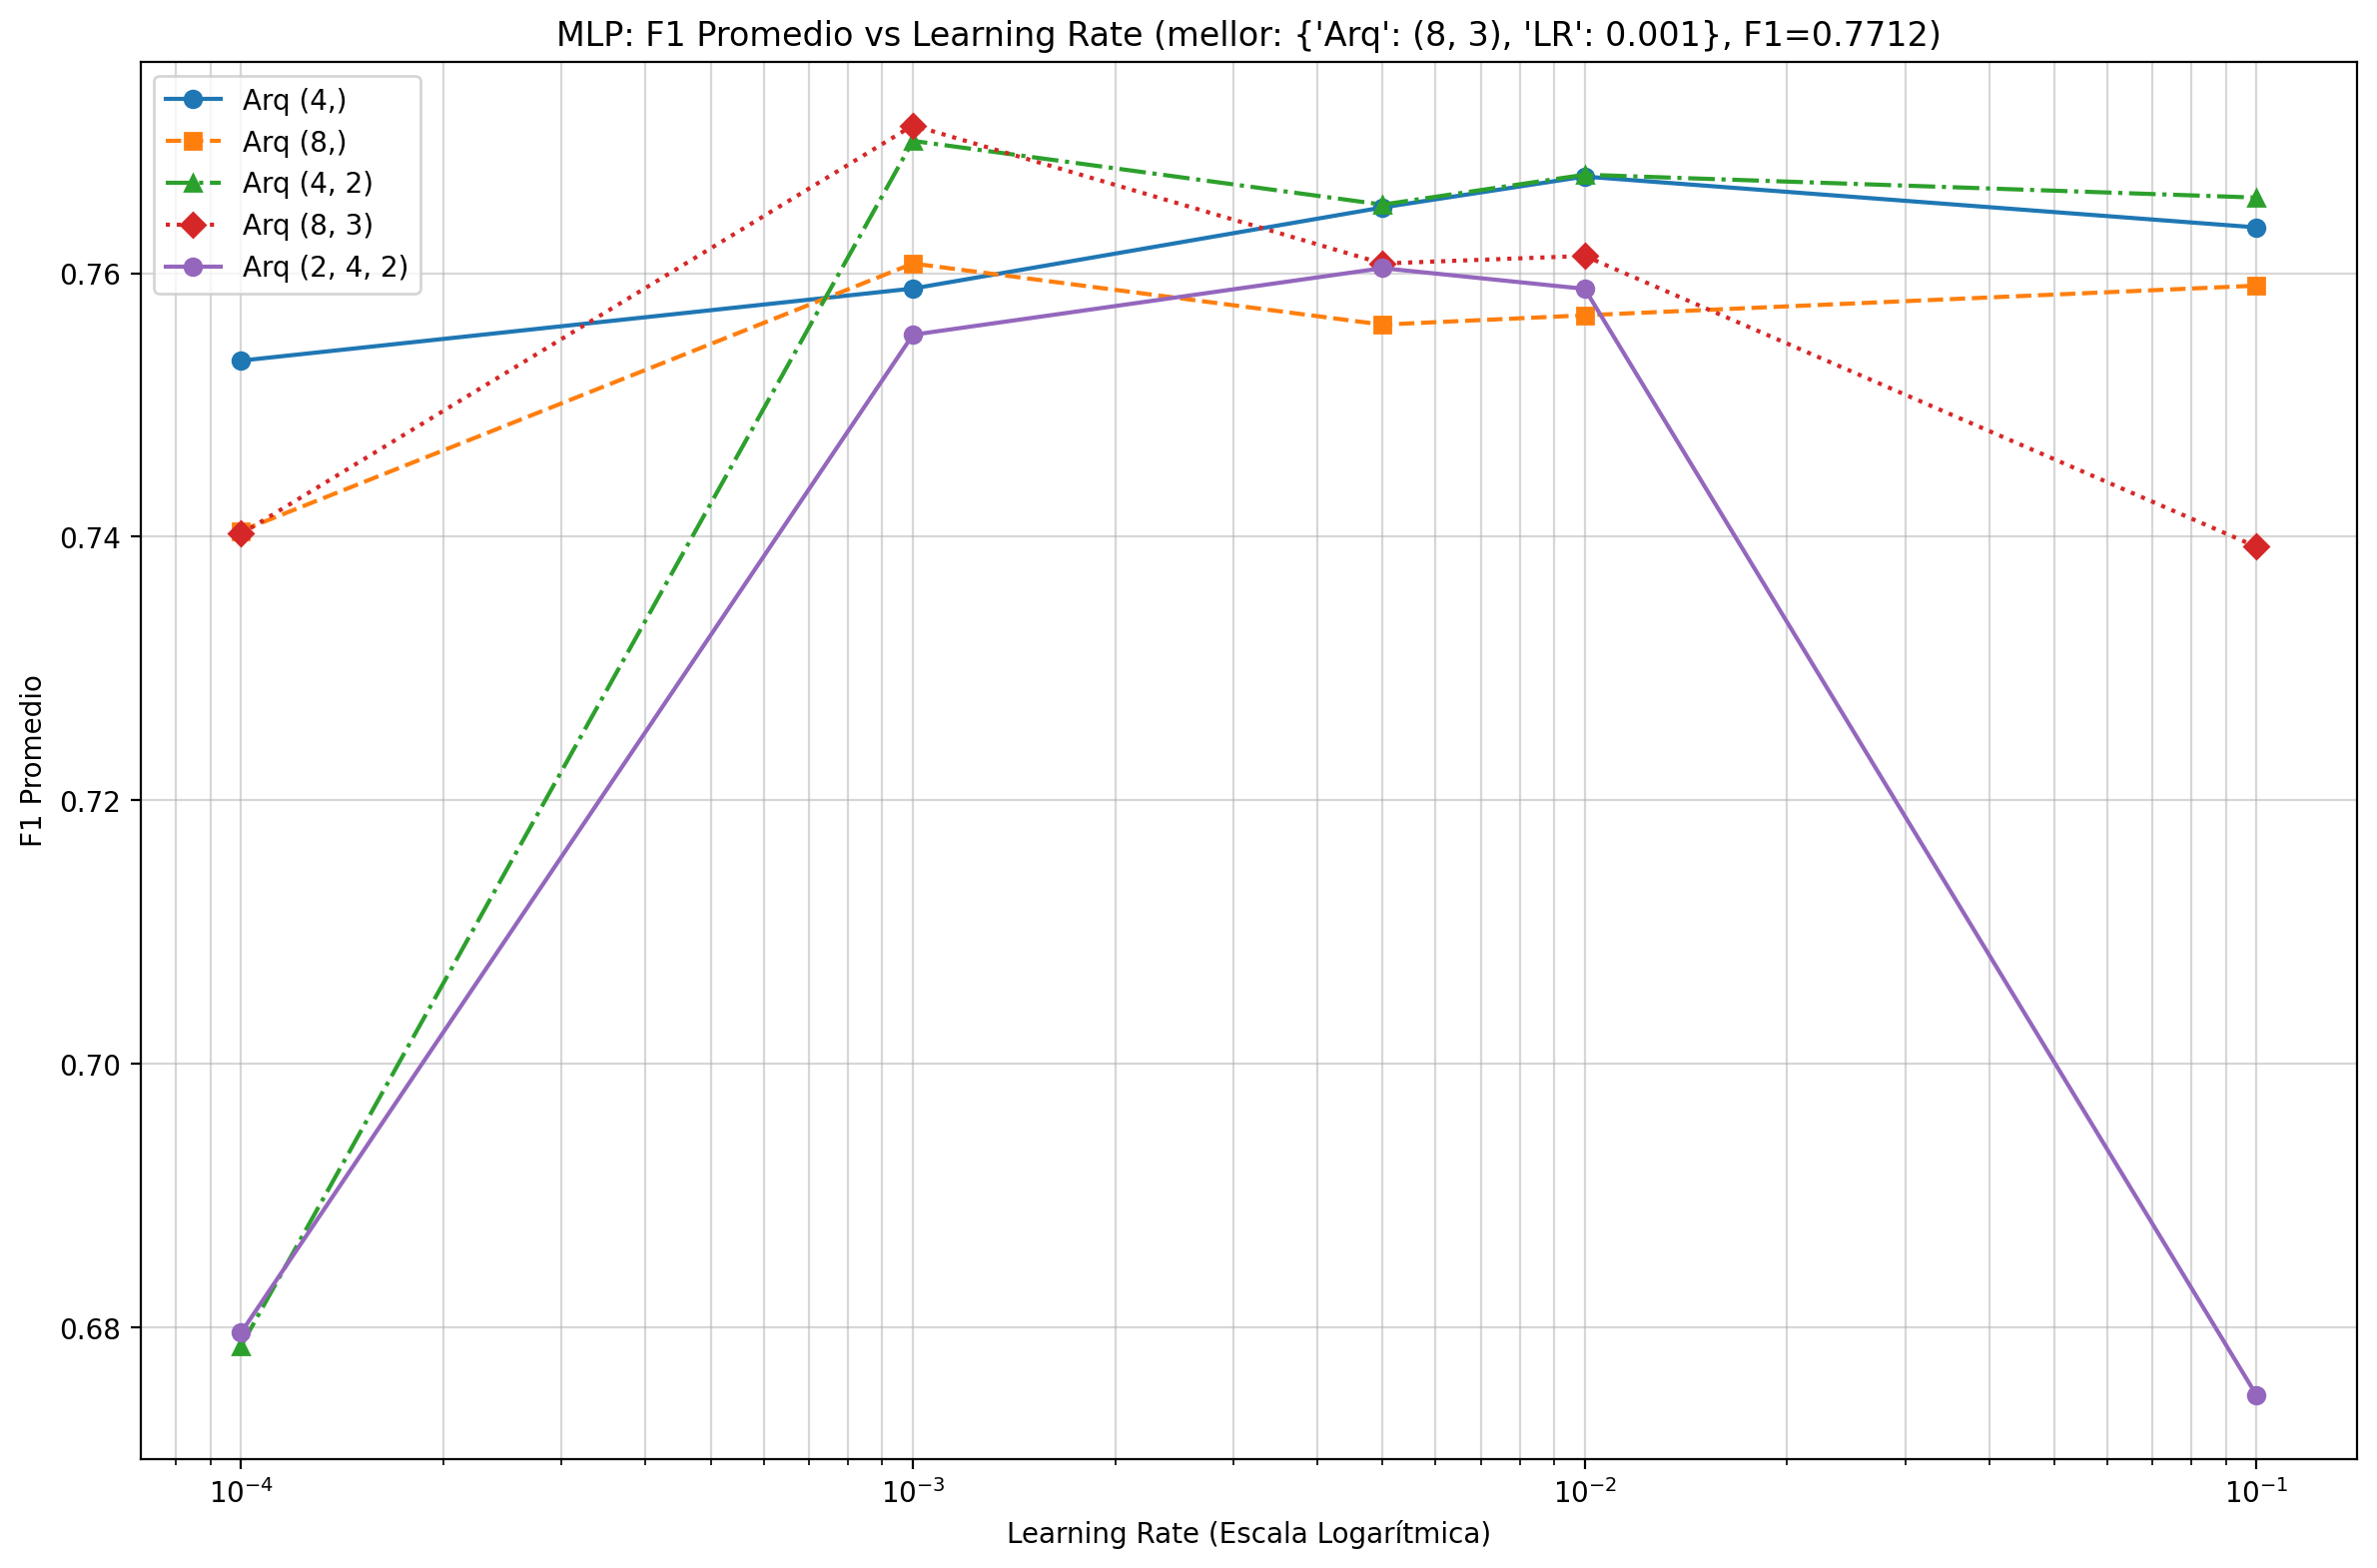

({'Arq': (8, 3), 'LR': 0.001}, np.float64(0.7712180089204455))

In [29]:
# Función de graficar
def mellor_mlp(bloques, indices_train_internos, indices_validacion_internos, arquitecturas, learning_rates, dib=False, metrica='kappa'):

    lista_dfs_train = []
    lista_dfs_val = []

    for i in range(len(indices_train_internos)):
        lista_dfs_train.append(xuntar_bloques(bloques, indices_train_internos[i]))
        lista_dfs_val.append(xuntar_bloques(bloques, indices_validacion_internos[i]))

    resultados = {}

    mellor_score = -1 # Antes mellor_kappa
    mellor_config = {}

    for arq in arquitecturas:
        nombre_arq = str(arq)
        resultados[nombre_arq] = []

        for lr in learning_rates:

            # Chamamos pasando a métrica correspondente
            score_avg = evaluar_mlp(lista_dfs_train, lista_dfs_val, arq, lr, metrica=metrica)

            resultados[nombre_arq].append(score_avg)

            if score_avg > mellor_score:
                mellor_score = score_avg
                mellor_config = {'Arq': arq, 'LR': lr}

    if dib:
        plt.figure(figsize=(12, 8))

        # Estilos y marcadores para diferenciar arquitecturas
        marcadores = ['o', 's', '^', 'D']
        estilos = ['-', '--', '-.', ':']

        for i, arq in enumerate(arquitecturas):
            nombre_arq = str(arq)
            y_valores = resultados[nombre_arq]

            # Usamos i % len para rotar estilos se hai moitas arquitecturas
            marker = marcadores[i % len(marcadores)]
            style = estilos[i % len(estilos)]

            plt.plot(learning_rates, y_valores, marker=marker, linestyle=style, label=f'Arq {nombre_arq}')

        # Modificamos o título e o eixe Y para que sexan dinámicos
        plt.title(f'MLP: {metrica.capitalize()} Promedio vs Learning Rate (mellor: {mellor_config}, {metrica.capitalize()}={mellor_score:.4f})')
        plt.xlabel('Learning Rate (Escala Logarítmica)')
        plt.ylabel(f'{metrica.capitalize()} Promedio')

        plt.xscale('log')
        plt.grid(True, which="both", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return mellor_config, mellor_score

tasas_aprendizaje = [0.0001, 0.001, 0.005, 0.01, 0.1]
lista_arquitecturas = [
    (4,),
    (8,),
    (4, 2),
    (8, 3),
    (2, 4, 2)
]

mellor_mlp(bloques, indices_train_internos, indices_validacion_internos, lista_arquitecturas, tasas_aprendizaje, dib=True, metrica=metrica)

## Adestramento dos modelos

Finalmente, nesta sección faremos uso de todo o que levamos elaborado ata este punto para entrenar todos os modelos. Recordemos o proceso

1. Empregamos a función `preparar_conxunto_datos` para tomar un dataframe de datos crudos e tratalos de forma completa.
2. Dividimos o dataframe en 6 bloques aleatorios de igual tamaño mediante `obter_bloques`.
3. Obtemos todas as combinacións de índices de conxuntos de adestramento, test e validación mediante as funcións `indices_conxuntos_externos` e `indices_conxuntos_internos`.
4. Obtemos os dataframes que conteñen os bloques de índices anteriores mediante a función `xuntar_bloques`.
5. Empregamos as funcións de adestramento dos modelos para cada combinación de bloques e iteramos sobre elas combinacións de hiperparámetros.
6. A mello configuración de hipeparámetros será aquela que, empregada para adestrar sobre os tres conxuntos externos, ten a mellor media de scores f1.



In [30]:
df = pd.read_csv("train.csv")

df_datos_filtrados = preparar_conxunto_datos(df=df,
                                             nome_etiquetas='quality',
                                             umbral_exito=7,
                                             alpha=0.95,
                                             nor=True,
                                             log=False,
                                             box=False)

bloques = obter_bloques(df_datos_filtrados, k=6, log=False)

conxuntos_train_externos = []
conxuntos_test_externos = []
conxuntos_train_internos = []
conxuntos_val_internos = []

indices_conxuntos_train_externos, indices_conxuntos_test_externos = indices_conxuntos_externos(
    range(len(bloques)), 1 / 3, log=False)

for i in range(len(indices_conxuntos_train_externos)):
    conxuntos_train_externos.append(xuntar_bloques(bloques, indices_conxuntos_train_externos[i], False))
    conxuntos_test_externos.append(xuntar_bloques(bloques, indices_conxuntos_test_externos[i], False))

    indices_conxuntos_train_internos, indices_conxuntos_val_internos = indices_conxuntos_internos(
        indices_conxuntos_train_externos[i], 1 / 4, log=False)

    for j in range(len(indices_conxuntos_train_internos)):
        conxuntos_train_internos.append(xuntar_bloques(bloques, indices_conxuntos_train_internos[j], False))
        conxuntos_val_internos.append(xuntar_bloques(bloques, indices_conxuntos_val_internos[j], False))

n_ext = len(indices_conxuntos_train_externos)
n_int_por_ext = len(indices_conxuntos_train_internos)

#### Modelos kNN



In [51]:
mellores_k = [] # K usado no mellor modelo

# Valores de k (os escollemos impares para evitar empate)
k_min = 1
k_max = 20
k_values = range(k_min, k_max + 1, 2)

for i in range(n_ext):
    mellor_k = -1
    mellor_score = -1
    
    # Conxuntos de adestramento e validacion
    lista_dfs_train = conxuntos_train_internos[i * n_int_por_ext:(i + 1) * n_int_por_ext]
    lista_dfs_val = conxuntos_val_internos[i * n_int_por_ext:(i + 1) * n_int_por_ext]

    # Iteramos sobre os hiperparámetros
    for k in k_values:
        score_avg = evaluar_knn(lista_dfs_train, lista_dfs_val, k, metrica=metrica)

        if score_avg > mellor_score:
            mellor_score = score_avg
            mellor_k = k
            
    mellores_k.append(mellor_k)
                    
# Adestramos agora os modelos para os mellores k sobre os distintos conxuntos externos e facemos a media para obter o mellor k
medias_scores = []
for i in range(len(mellores_k)):
    
    media_scores = 0
        
    for i in range(len(conxuntos_train_externos)):
        conxunto_train = conxuntos_train_externos[i]
        conxunto_test = conxuntos_test_externos[i]
    
        X_train = conxunto_train.drop('quality', axis=1).values
        y_train = conxunto_train['quality'].values

        X_test = conxunto_test.drop('quality', axis=1).values
        y_test = conxunto_test['quality'].values
                
        modelo_knn = KNeighborsClassifier(n_neighbors=mellores_k[i])
        modelo_knn.fit(X_train, y_train)
        y_pred = modelo_knn.predict(X_test)
        
        if metrica == 'kappa':
            score_test = cohen_kappa_score(y_test, y_pred)
        elif metrica == 'accuracy':
            score_test = accuracy_score(y_test, y_pred)
        elif metrica == 'precision':
            score_test = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'recall':
            score_test = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'f1':
            score_test = f1_score(y_test, y_pred, average='weighted', zero_division=0)
            
        media_scores += score_test
        
    media_scores /= len(conxuntos_train_externos)
    medias_scores.append(media_scores)

mellor_k = mellores_k[np.argmax(medias_scores)]

# Rendemento final dependendo da métrica global escollida
print("\n--- Modelos knn ---")
print("Como resultado da validación cruzada anidada sobre os modelos knn, obtivose o mellor modelo para:")
print(f" - Hiperparámetro k = {mellor_k}, sendo o rango destes dende {k_min} ata {k_max}")
print(f" - Score {metrica} do modelo adestrado co conxunto externo: {max(medias_scores):.4f}")


--- Modelos knn ---
Como resultado da validación cruzada anidada sobre os modelos knn, obtivose o mellor modelo para:
 - Hiperparámetro k = 5, sendo o rango destes dende 1 ata 20
 - Score f1 do modelo adestrado co conxunto externo: 0.7511


#### Modelos de regresión loxística



In [32]:
mellores_penalty = []
mellores_c = []

penalties = ['l2', None]
c_values = [0.001, 0.01, 0.1, 0.2, 0.5, 1, 10]

for i in range(n_ext):
    mellor_score = -1
    mellor_penalty = None
    mellor_c = -1
    lista_dfs_train = conxuntos_train_internos[i * n_int_por_ext:(i + 1) * n_int_por_ext]
    lista_dfs_val = conxuntos_val_internos[i * n_int_por_ext:(i + 1) * n_int_por_ext]
    for penalty in penalties:
        if penalty is None:
            score_avg = evaluar_loxistica(lista_dfs_train, lista_dfs_val, penalty=None, C=1.0, metrica=metrica)
            if score_avg > mellor_score:
                mellor_score = score_avg
                mellor_penalty = None
        else:
            for c in c_values:
                score_avg = evaluar_loxistica(lista_dfs_train, lista_dfs_val, penalty='l2', C=c, metrica=metrica)
                if score_avg > mellor_score:
                    mellor_score = score_avg
                    mellor_penalty = 'l2'
                    mellor_c = c
    mellores_penalty.append(mellor_penalty)
    mellores_c.append(mellor_c)

medias_scores = []
for i in range(len(mellores_penalty)):
    suma_scores = 0
    for j in range(n_ext):
        conxunto_train = conxuntos_train_externos[j]
        conxunto_test = conxuntos_test_externos[j]
        X_train = conxunto_train.drop('quality', axis=1).values
        y_train = conxunto_train['quality'].values
        X_test = conxunto_test.drop('quality', axis=1).values
        y_test = conxunto_test['quality'].values
        if mellores_penalty[i] is None:
            modelo_loxistica = LogisticRegression(penalty=None)
        else:
            modelo_loxistica = LogisticRegression(penalty=mellores_penalty[i], C=mellores_c[i])
        modelo_loxistica.fit(X_train, y_train)
        y_pred = modelo_loxistica.predict(X_test)  # <-- faltaba esto
        if metrica == 'f1':
            score_test = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'accuracy':
            score_test = accuracy_score(y_test, y_pred)
        elif metrica == 'precision':
            score_test = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'recall':
            score_test = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'kappa':
            score_test = cohen_kappa_score(y_test, y_pred)
        suma_scores += score_test
    medias_scores.append(suma_scores / n_ext)

mellor_indice = np.argmax(medias_scores)
mellor_penalty = mellores_penalty[mellor_indice]
mellor_c = mellores_c[mellor_indice]

print("\n--- Modelos de regresión loxística ---")
print(f" - Hiperparámetro penalty = {mellores_penalty[mellor_indice]}, sendo as posibilidades {penalties}")
if mellores_penalty[mellor_indice] is None:
    print(f" - O hiperparámetro C non aplica para penalty = None")
else:
    print(f" - Hiperparámetro C = {mellores_c[mellor_indice]}, sendo as posibilidades {c_values}")
print(f" - Score {metrica} medio: {medias_scores[mellor_indice]:.4f}")


--- Modelos de regresión loxística ---
 - Hiperparámetro penalty = l2, sendo as posibilidades ['l2', None]
 - Hiperparámetro C = 10, sendo as posibilidades [0.001, 0.01, 0.1, 0.2, 0.5, 1, 10]
 - Score f1 medio: 0.7504


#### Modelos de árbores de decisión



In [33]:
mellor_depth_list = []
mellor_leaf_list = []
mellor_split_list = []

rango_profundidade = range(1, 15)
pares_leaf_split = [(1, 2), (1, 5), (2, 5), (10, 20), (10, 50), (50, 100)]

for i in range(n_ext):
    lista_dfs_train = conxuntos_train_internos[i * n_int_por_ext:(i + 1) * n_int_por_ext]
    lista_dfs_val = conxuntos_val_internos[i * n_int_por_ext:(i + 1) * n_int_por_ext]
    mellor_score = -1
    for leaf, split in pares_leaf_split:
        for depth in rango_profundidade:
            score_avg = evaluar_cart(lista_dfs_train, lista_dfs_val, depth, leaf, split, metrica=metrica)
            if score_avg > mellor_score:
                mellor_score = score_avg
                mellor_depth_valor = depth
                mellor_leaf_valor = leaf
                mellor_split_valor = split
    mellor_depth_list.append(mellor_depth_valor)
    mellor_leaf_list.append(mellor_leaf_valor)
    mellor_split_list.append(mellor_split_valor)

medias_scores = []
for i in range(len(mellor_depth_list)):
    modelo_cart = DecisionTreeClassifier(
        max_depth=mellor_depth_list[i],
        min_samples_leaf=mellor_leaf_list[i],
        min_samples_split=mellor_split_list[i],
        random_state=42
    )
    suma_scores = 0
    for j in range(n_ext):
        conxunto_train = conxuntos_train_externos[j]
        conxunto_test = conxuntos_test_externos[j]
        X_train = conxunto_train.drop('quality', axis=1).values
        y_train = conxunto_train['quality'].values
        X_test = conxunto_test.drop('quality', axis=1).values
        y_test = conxunto_test['quality'].values
        modelo_cart.fit(X_train, y_train)
        y_pred = modelo_cart.predict(X_test)
        if metrica == 'f1':
            score_test = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'accuracy':
            score_test = accuracy_score(y_test, y_pred)
        elif metrica == 'precision':
            score_test = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'recall':
            score_test = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'kappa':
            score_test = cohen_kappa_score(y_test, y_pred)
        suma_scores += score_test
    medias_scores.append(suma_scores / n_ext)

mellor_indice = np.argmax(medias_scores)
mellor_depth = mellor_depth_list[mellor_indice]
mellor_leaf = mellor_leaf_list[mellor_indice]
mellor_split = mellor_split_list[mellor_indice]

print("\n--- Modelos de árbores de decisión (CART) ---")
print(f" - Hiperparámetro max_depth = {mellor_depth}, rango: {list(rango_profundidade)}")
print(f" - Hiperparámetro min_samples_leaf = {mellor_leaf}")
print(f" - Hiperparámetro min_samples_split = {mellor_split}")
print(f" - Score {metrica} medio: {max(medias_scores)}")


--- Modelos de árbores de decisión (CART) ---
 - Hiperparámetro max_depth = 6, rango: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 - Hiperparámetro min_samples_leaf = 50
 - Hiperparámetro min_samples_split = 100
 - Score f1 medio: 0.7489290405706459


#### Modelos de perceptrón multicapa



In [34]:
mellores_arq = []
mellores_lr = []
tasas_aprendizaje = [0.001, 0.005, 0.01]
lista_arquitecturas = [(4,), (8,), (4, 2), (8, 3)] # Quitamos algunhas que sempre daban peor, para que tarde menos

for i in range(n_ext):
    mellores_score = -1
    lista_dfs_train = conxuntos_train_internos[i * n_int_por_ext:(i + 1) * n_int_por_ext]
    lista_dfs_val = conxuntos_val_internos[i * n_int_por_ext:(i + 1) * n_int_por_ext]
    for arq in lista_arquitecturas:
        for lr in tasas_aprendizaje:
            score_avg = evaluar_mlp(lista_dfs_train, lista_dfs_val, arq, lr, metrica=metrica)
            if score_avg > mellores_score:
                mellor_score = score_avg
                mellor_arq_valor = arq
                mellor_lr_valor = lr
    mellores_arq.append(mellor_arq_valor)
    mellores_lr.append(mellor_lr_valor)

medias_scores = []
for i in range(len(mellores_arq)):
    modelo_mlp = MLPClassifier(
        hidden_layer_sizes=mellores_arq[i],
        learning_rate_init=mellores_lr[i],
        max_iter=10000,
        random_state=42
    )
    suma_scores = 0  
    for j in range(n_ext):  
        conxunto_train = conxuntos_train_externos[j]
        conxunto_test = conxuntos_test_externos[j]  
        X_train = conxunto_train.drop('quality', axis=1).values
        y_train = conxunto_train['quality'].values
        X_test = conxunto_test.drop('quality', axis=1).values
        y_test = conxunto_test['quality'].values
        modelo_mlp.fit(X_train, y_train)
        y_pred = modelo_mlp.predict(X_test)
        if metrica == 'f1':
            score_test = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'accuracy':
            score_test = accuracy_score(y_test, y_pred)
        elif metrica == 'precision':
            score_test = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'recall':
            score_test = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        elif metrica == 'kappa':
            score_test = cohen_kappa_score(y_test, y_pred)
        suma_scores += score_test
    medias_scores.append(suma_scores / n_ext)

mellor_indice = np.argmax(medias_scores)  
mellor_arq = mellores_arq[mellor_indice]
mellor_lr = mellores_lr[mellor_indice]

print("\n--- Modelos de perceptrón multicapa (MLP) ---")
print(f" - hidden_layer_sizes = {mellores_arq[mellor_indice]}, posibilidades: {lista_arquitecturas}")
print(f" - learning_rate_init = {mellores_lr[mellor_indice]}, posibilidades: {tasas_aprendizaje}")
print(f" - Score {metrica} medio: {medias_scores[mellor_indice]:.4f}")


--- Modelos de perceptrón multicapa (MLP) ---
 - hidden_layer_sizes = (8, 3), posibilidades: [(4,), (8,), (4, 2), (8, 3)]
 - learning_rate_init = 0.01, posibilidades: [0.001, 0.005, 0.01]
 - Score f1 medio: 0.7603


## Resultados e conclusións



Podemos ver como os modelos contan cun valor de f1 entre 0.7407, neste caso para o kNN, e 0.7603, para o perceptrón multicapa. Este valor f1 calcúlase do dobre da precisión polo recall, entre a suma da precisión e o recall, polo tanto, podemos saber que canto maior sexa este score mellor será o modelo.

Os catro modelos obtiveron resultados moi similares, cunha diferenza de apenas 0.02 entre o mellor e o peor. O perceptrón multicapa foi o modelo con maior f1 \(0.7603\), seguido da regresión loxística \(0.7504\), o árbore de decisión \(0.7489\) e finalmente o kNN \(0.7407\).

Cabe destacar que os hiperparámetros seleccionados teñen sentido para cada modelo. O kNN con k=5 indica que o modelo require un número moderado de veciños para xeneralizar ben. A regresión loxística con C=10 e penalty L2 prefire pouca regularización, o que suxire que a maioría das variables son relevantes. A árbore de decisión con max\_depth=6 e parámetros conservadores de folla evita o sobreaxuste mantendo certa complexidade. O perceptrón multicapa con arquitectura \(8,3\) e velocidade de aprendizaxe 0.01 é unha rede modesta pero suficiente para este problema.

En conclusión, o perceptrón multicapa e a regresión loxística son os modelos máis axeitados para este dataset. As pequenas diferenzas entre modelos suxiren que o límite de rendemento está máis condicionado pola natureza deste propio dataset e o desbalanceo de clases. Todos os modelos alcanzan un f1 maior de 0.74, o cal se pode considerar unha capacidade de predicción sólida, polo que podemos concluír que o tratamento dos datos é relativamente correcto.


# Test

Procederemos agora a probar o rendemento dos anteriores modelos no conxunto de test proporcionado na clase da entrega.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,6.2,0.24,0.29,13.3,0.039,49.0,130.0,0.9952,3.33,0.46,11.0,8
1,6.3,0.39,0.24,6.9,0.069,9.0,117.0,0.9942,3.15,0.35,10.2,4
2,6.6,0.24,0.35,7.7,0.031,36.0,135.0,0.9938,3.19,0.37,10.5,5
3,7.0,0.35,0.24,1.9,0.040,21.0,144.0,0.9923,3.35,0.38,11.0,5
4,6.9,0.30,0.49,7.6,0.057,25.0,156.0,0.9962,3.43,0.63,11.0,7


(490, 12)


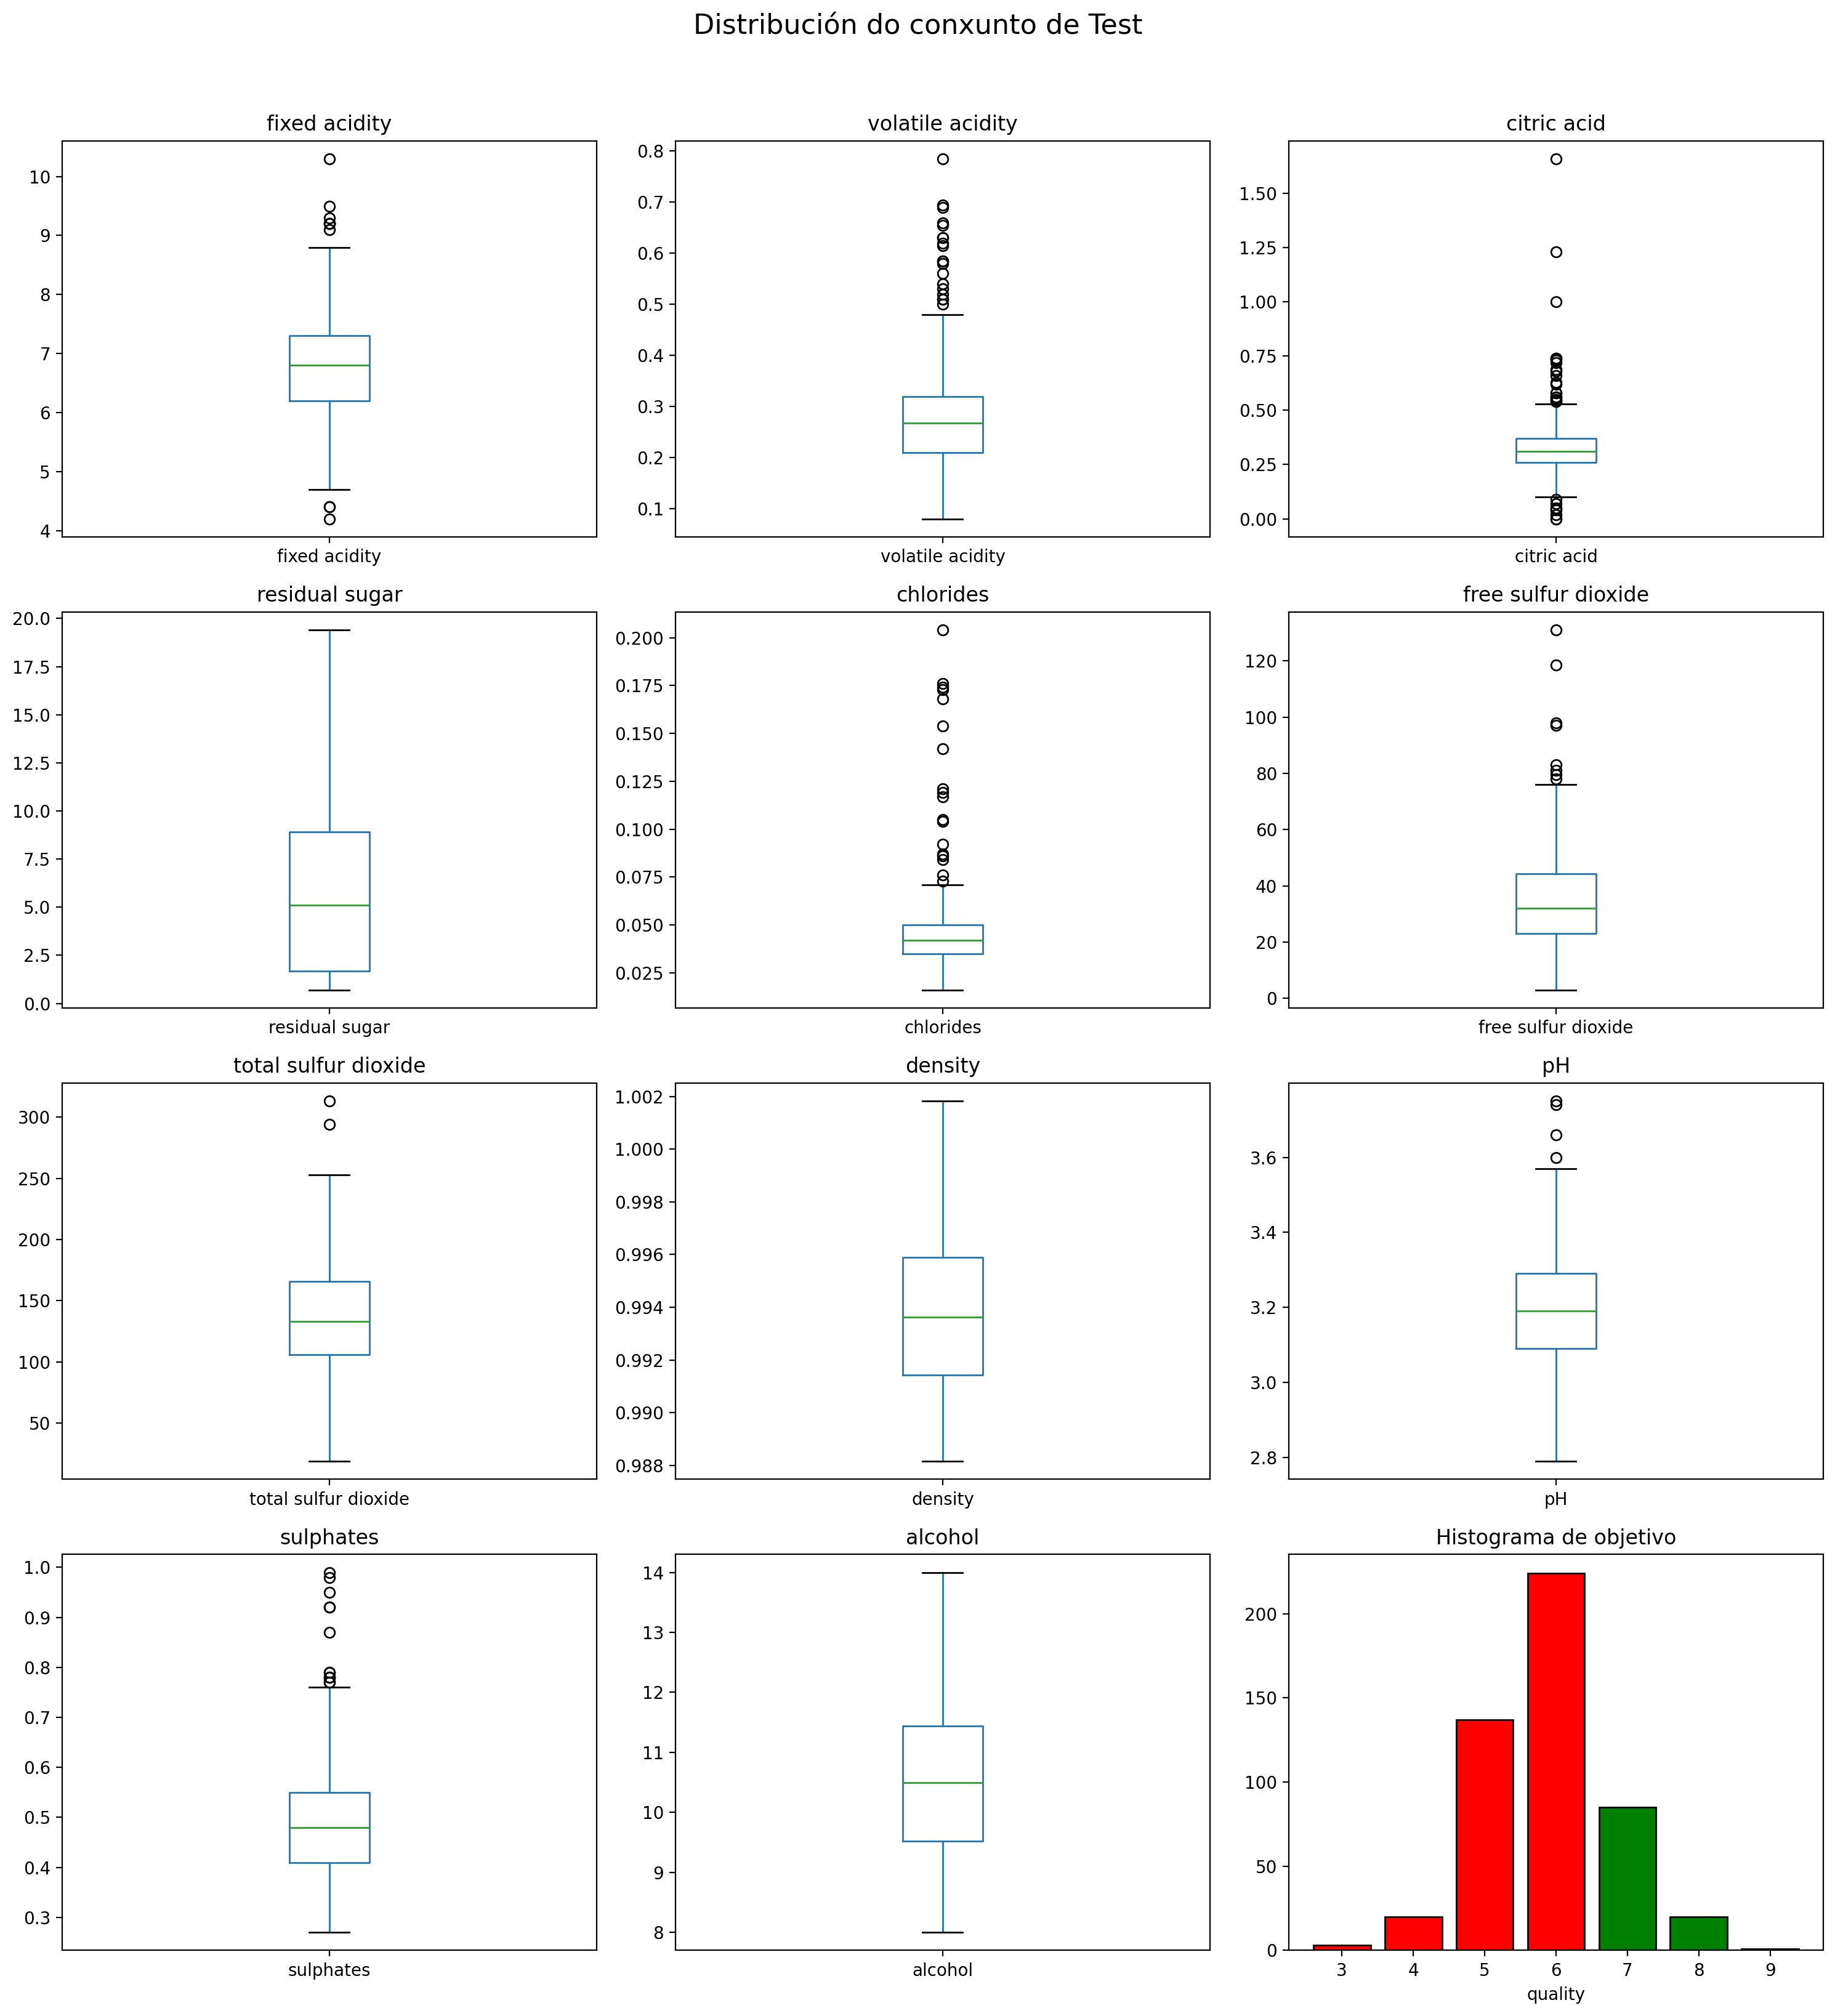

In [35]:
df_adestramento = pd.read_csv("train.csv")
df_test = pd.read_csv("test_1.csv")

display(df_test.head())
print(df_test.shape)
representar_boxplots(df_test, 'quality', 'Distribución do conxunto de Test')

A simple vista, a distribución da variable obxectivo é a mesma que no csv de adestramento. 

Ademáis, non hai ningún valor negativo ou inválido, e as distribucións univariables son moito menos dispersas.

Só hai 14 elementos duplicados que non eliminaremos, posto que poderían ser medicións normais. En canto aos outliers, non os imos eliminar, xa que este conxunto non é en ningún momento para entrenar os modelos.

Imos reducir a dimensionalidade xa coas mesmas variables que tiñamos escollidas anteriormente, posto que as outras 6 columnas non se usan para nada.


In [36]:
# Non gardamos o novo df, é para log solo
eliminar_duplicados(df_test, log=True)
eliminar_imposibles(df_test, True)
eliminar_nan(df_test, 'quality', umbral=0, log=True)

# Reducimos a dimensionalidade ao inicio, posto que xa tiñamos decidido de antes as mellores columnas
columnas = ['alcohol', 'density', 'chlorides', 'total sulfur dioxide', 'residual sugar', 'quality']

df_adestramento = df_adestramento.loc[:, columnas]
df_test = df_test.loc[:, columnas]


--- Clases de equivalencia ---
Número de clases de equivalencia con máis dunha fila: 14
Total de filas a eliminar: 14
Dimensións finais tras eliminar duplicados: (476, 12)

--- Filas imposibles ---
Total de filas nas que se substituíu algún valor por NaN: 0
Dimensións finais tras substituír: (490, 12)

--- Valores NaN (umbral: 0%) ---
Filas eliminadas por quality=NaN: 0
Filas eliminadas por ter unha proporción de máis do 0% de NaN: 0
Filas con NaN substituídos con mediana: 0
Dimensións orixinais: (490, 12)
Dimensións finais: (490, 12)


Atopámonos agora con un lixeiro inconveniente. Debemos evitar a filtración de datos ao conxunto de test. Esto tradúcese principalmente en dúas cousas coas que temos que ter coidado:

- Na función de eliminar os NaN, debemos substituír os NaN pola mediana do conxunto de **adestramento**, en lugar da mediana do propio conxunto de **test**.
- Á hora de normalizar, debemos normalizar coa media e a desviación típica da distribución do conxunto de **adestramento**, e non as do conxunto de **test**.

Estos dous matices tradúcense en que temos que modificar lixeiramente as funcións que xa tiñamos, o cal faremos a continuación.



In [37]:
def eliminar_nan_test(df, nome_etiquetas, valor_mediana, umbral=0.15, log=False, metodo='mediana'):

    # Borramos as filas onde a etiqueta é NaN
    df_limpo = df.dropna(subset=[nome_etiquetas])

    # Calculamos a proporción de NaN por fila
    proporcion_nan = df_limpo.isna().sum(axis=1) / len(df_limpo.columns)

    # Gardamos as filas que teñan máis proporción de NaN que o que permitimos
    filas_moitos_nan = proporcion_nan > umbral

    if log:
        print(f"\n--- Valores NaN (umbral: {umbral*100}%) ---")
        print(f"Filas eliminadas por quality=NaN: {len(df) - len(df_limpo)}")
        print(
            f"Filas eliminadas por ter unha proporción de máis do {umbral*100}% de NaN: {filas_moitos_nan.sum()}"
        )
        print(
            f"Filas con NaN substituídos con mediana: {((proporcion_nan > 0) & (proporcion_nan <= umbral)).sum()}"
        )

    # Eliminamos as filas con máis do umbral de NaN
    df_limpo = df_limpo[~filas_moitos_nan]

    # Substituíos os NaN restantes pola mediana, ou borrar todos
    if metodo == 'mediana':
        df_limpo = df_limpo.fillna(valor_mediana)
    elif metodo == 'borrar':
        df_limpo = df_limpo.dropna()

    if log:
        print(f"Dimensións orixinais: {df.shape}")
        print(f"Dimensións finais: {df_limpo.shape}")

    return df_limpo

In [38]:
from sklearn.preprocessing import StandardScaler

def normalizar_test(df, nome_etiquetas, escalador, log=False):
    x = df.drop(nome_etiquetas, axis=1)
    y = df[nome_etiquetas]

    x_scaled = escalador.transform(x)

    df_normalizado = pd.DataFrame(x_scaled, columns=x.columns, index=x.index)
    df_normalizado[nome_etiquetas] = y.values
    
    return df_normalizado
    

df_normalizado = normalizar(df_redimensionado, 'quality', True)

Debemos de ter en conta neste punto como facer correctamente o preprocesado de datos do novo dataframe. Neste caso, é necesario facer todo o preprocesado de datos tendo en conta o dataframe de adestramento, por tanto usaremos a mediana de adestramento e normalizaremos os datos según como se normalizaron os datos de adestramento.

In [39]:
def preprocesar_datos_test(df_adestramento, df_test, nome_etiquetas=None, umbral_exito=0, log=False):
    
    df_sen_duplicados_adestramento = eliminar_duplicados(df_adestramento, log=log)

    df_sen_imposibles_adestramento = eliminar_imposibles(df_sen_duplicados_adestramento, log=log)
    df_sen_imposibles_test = eliminar_imposibles(df_test, log=log)

    cols_analisis_adestramento = df_sen_imposibles_adestramento.columns.drop(nome_etiquetas)
    cols_analisis_test = df_sen_imposibles_test.columns.drop(nome_etiquetas)
    
    df_sen_outliers_adestramento = eliminar_outliers(df_sen_imposibles_adestramento, columnas=cols_analisis_adestramento, log=log)

    df_final_adestramento = eliminar_nan(df_sen_outliers_adestramento, nome_etiquetas, log=log)
    df_final_test = eliminar_nan_test(df_sen_imposibles_test, nome_etiquetas,df_final_adestramento.median(), log=log) #este eliminar nan é distinto, hai que pasar o valor da media de adestramento

    df_final_adestramento[nome_etiquetas] = (df_final_adestramento[nome_etiquetas] >= umbral_exito).astype(int)
    df_final_test[nome_etiquetas] = (df_final_test[nome_etiquetas] >= umbral_exito).astype(int)

    return df_final_adestramento,df_final_test


df_adestramento_preprocesado, df_test_preprocesado = preprocesar_datos_test(df_adestramento, df_test, 'quality', 7, True)


--- Clases de equivalencia ---
Número de clases de equivalencia con máis dunha fila: 303
Total de filas a eliminar: 356
Dimensións finais tras eliminar duplicados: (3555, 6)

--- Filas imposibles ---
Total de filas nas que se substituíu algún valor por NaN: 79
Dimensións finais tras substituír: (3555, 6)

--- Filas imposibles ---
Total de filas nas que se substituíu algún valor por NaN: 0
Dimensións finais tras substituír: (490, 6)

--- Outliers ---
Outliers por columna:
alcohol                  15
density                  54
chlorides               164
total sulfur dioxide     33
residual sugar           30
dtype: int64
Filas eliminadas: 279
Dimensións orixinais: (3555, 6)
Dimensións finais: (3276, 6)

--- Valores NaN (umbral: 15.0%) ---
Filas eliminadas por quality=NaN: 0
Filas eliminadas por ter unha proporción de máis do 15.0% de NaN: 868
Filas con NaN substituídos con mediana: 0
Dimensións orixinais: (3276, 6)
Dimensións finais: (2408, 6)

--- Valores NaN (umbral: 15.0%) ---
Fila

In [40]:
def preparar_conxunto_datos_test(df_adestramento,
                             df_test,
                            nome_etiquetas='quality',
                            umbral_exito=7,
                            alpha=0.95,
                            nor=True,
                            log=False,
                            box=False):
    df_adestramento, df_test = preprocesar_datos_test(df_adestramento, df_test, 'quality', 7, True)
   

    if nor:
        df_adestramento, escalador = normalizar(df_adestramento, nome_etiquetas, log, devolver_escalador = True)
        df_test = normalizar_test(df_test, nome_etiquetas, escalador, log)

    if log:
        display(df_adestramento.head())
        display(df_adestramento.tail())
        
        display(df_test.head())
        display(df_test.tail())

    if box:
        representar_boxplots(df_adestramento, nome_etiquetas,
                             "Boxplot das variables procesadas seleccionadas de adestramento")
        
        representar_boxplots(df_test, nome_etiquetas,
                             "Boxplot das variables procesadas seleccionadas de test")

    return df_adestramento, df_test


--- Clases de equivalencia ---
Número de clases de equivalencia con máis dunha fila: 303
Total de filas a eliminar: 356
Dimensións finais tras eliminar duplicados: (3555, 6)

--- Filas imposibles ---
Total de filas nas que se substituíu algún valor por NaN: 79
Dimensións finais tras substituír: (3555, 6)

--- Filas imposibles ---
Total de filas nas que se substituíu algún valor por NaN: 0
Dimensións finais tras substituír: (490, 6)

--- Outliers ---
Outliers por columna:
alcohol                  15
density                  54
chlorides               164
total sulfur dioxide     33
residual sugar           30
dtype: int64
Filas eliminadas: 279
Dimensións orixinais: (3555, 6)
Dimensións finais: (3276, 6)

--- Valores NaN (umbral: 15.0%) ---
Filas eliminadas por quality=NaN: 0
Filas eliminadas por ter unha proporción de máis do 15.0% de NaN: 868
Filas con NaN substituídos con mediana: 0
Dimensións orixinais: (3276, 6)
Dimensións finais: (2408, 6)

--- Valores NaN (umbral: 15.0%) ---
Fila

,alcohol,density,chlorides,total sulfur dioxide,residual sugar,quality
0,-0.816172,1.298200,0.382615,1.651846,1.469136,0
3,0.333633,0.555390,-0.217279,-0.304504,0.742751,0
4,-0.816172,1.093042,-1.117121,1.386169,0.888028,0
6,-1.226816,0.060183,0.282633,-1.077382,-0.627002,0
7,-1.473202,1.269902,0.482598,1.989980,0.867274,0


,alcohol,density,chlorides,total sulfur dioxide,residual sugar,quality
3908,-0.405527,0.838365,-0.317261,-0.401113,0.929536,0
3909,0.333633,-0.031784,0.882527,0.154393,0.140890,0
3910,0.333633,-0.717999,-0.517226,-1.512127,-1.062833,0
3912,0.826406,-0.930230,-0.417244,-0.860010,-0.917556,0
3917,-0.980429,0.201671,1.782369,0.758205,-0.979817,0


,alcohol,density,chlorides,total sulfur dioxide,residual sugar,quality
0,0.333633,0.484646,-0.317261,-0.159589,1.489890,1
1,-0.323398,0.130927,2.682211,-0.473571,0.161644,0
2,-0.077012,-0.010561,-1.117121,-0.038826,0.327675,0
3,0.333633,-0.541139,-0.217279,0.178546,-0.876048,0
4,0.333633,0.838365,1.482422,0.468375,0.306921,1


,alcohol,density,chlorides,total sulfur dioxide,residual sugar,quality
485,0.990664,0.152150,-0.417244,-0.111284,1.386120,1
486,-1.308945,1.867687,0.882527,0.903119,2.735120,0
487,0.580019,-1.283949,-1.217103,-0.618486,-0.668510,1
488,0.662148,-0.074230,-2.216927,-0.787553,0.441821,0
489,-1.473202,1.015224,1.382439,1.893370,0.514459,0


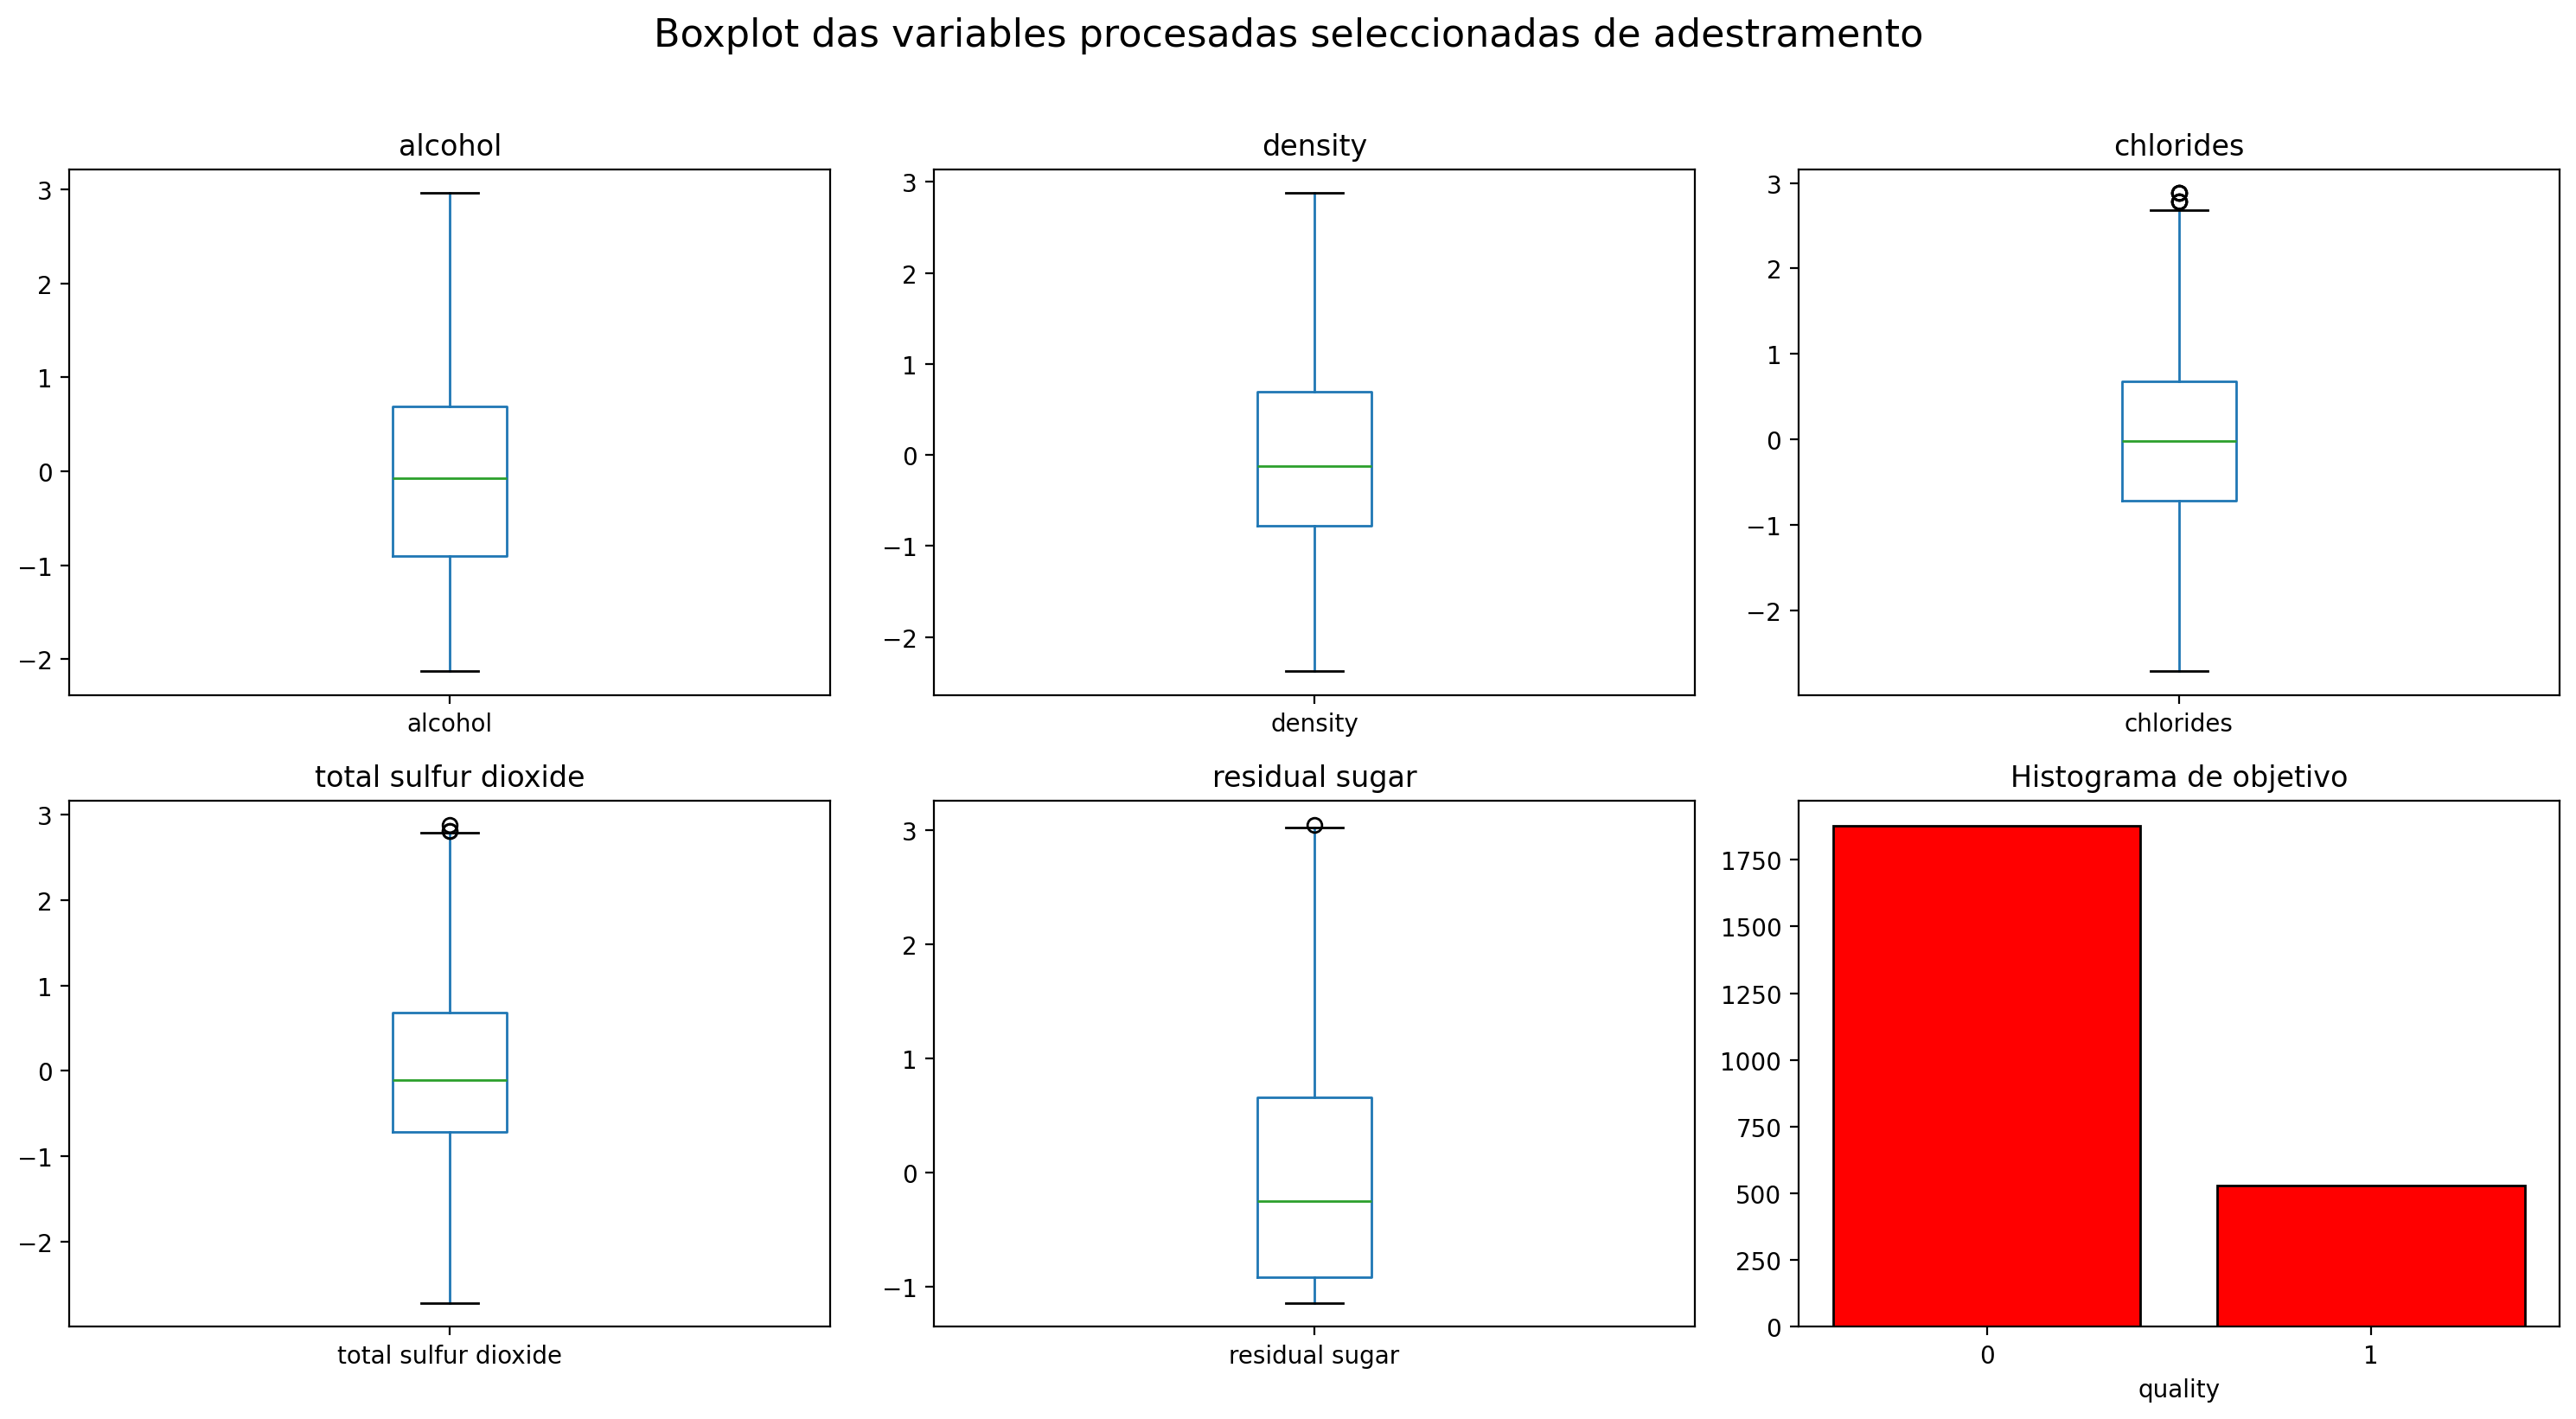

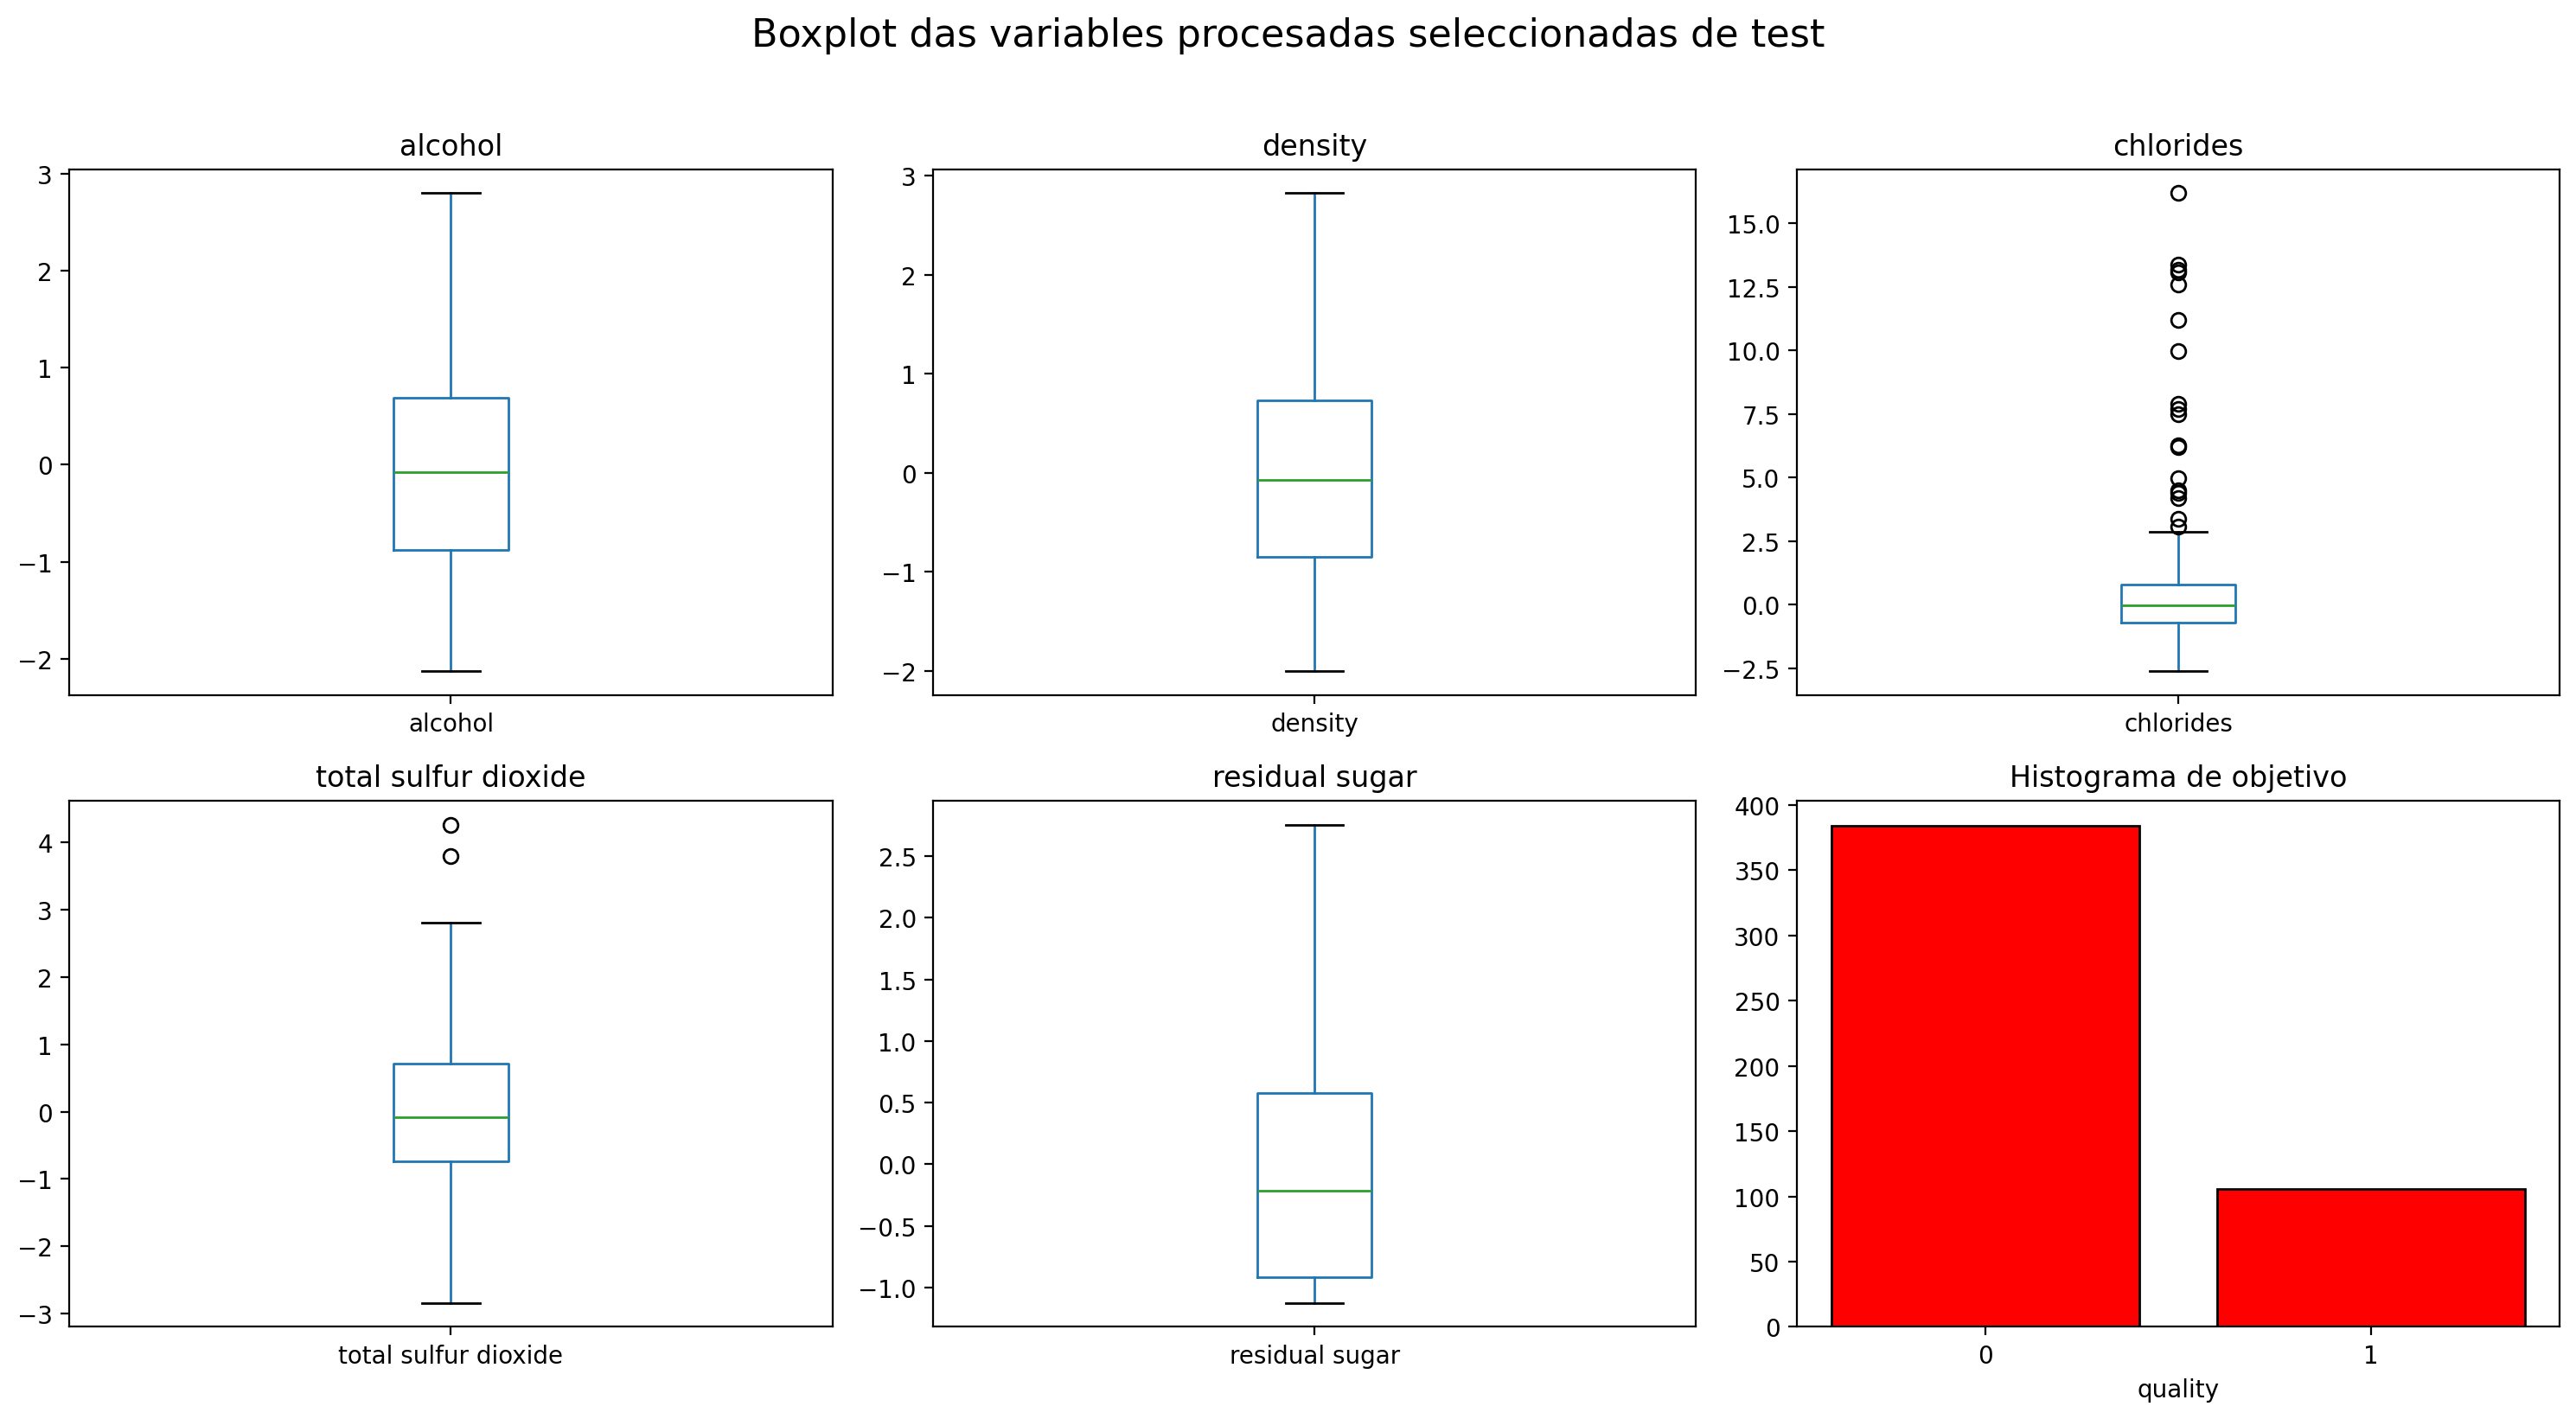

In [41]:
df_adestramento_final, df_test_final = preparar_conxunto_datos_test(df_adestramento,df_test,log=True,box=True)

#### Adestramento final cos mellores hiperparámeros

Anteriormente na validación cruzada obtiñamos as mellores configuracións para cada tipo de modelo \(por exemplo, con KNN o mellor K, con redes neuronais a mellor arquitectura e taxa de aprendizaxe inicial, etc\)

Agora procedemos a adestrar con eses hiperparámetros o modelo empregando o conxunto de train completo, para posteriormente avalialo co conxunto de test


In [42]:
X_train_final = df_adestramento_final.drop('quality', axis=1).values
y_train_final = df_adestramento_final['quality'].values

X_test_final = df_test_final.drop('quality', axis=1).values
y_test_final = df_test_final['quality'].values

In [52]:
# A variable que obtivemos antes
modelo_knn_final = KNeighborsClassifier(n_neighbors=mellor_k)
modelo_knn_final.fit(X_train_final, y_train_final)
y_pred_final = modelo_knn_final.predict(X_test_final)

# Usamos a métrica f1 para todo
score_f1_test = f1_score(y_test_final, y_pred_final, average='weighted', zero_division=0)

print("\n--- Avaliación Final do Modelo KNN ---")
print(f" - Hiperparámetro empregado (K): {mellor_k}")
print(f" - F1 Score obtido no conxunto de test: {score_f1_test:.4f}")


--- Avaliación Final do Modelo KNN ---
 - Hiperparámetro empregado (K): 5
 - F1 Score obtido no conxunto de test: 0.7644


In [50]:
modelo_rl_final = LogisticRegression(penalty=mellor_penalty, C=mellor_c)
modelo_rl_final.fit(X_train_final, y_train_final)
y_pred_final = modelo_rl_final.predict(X_test_final)

score_f1_test = f1_score(y_test_final, y_pred_final, average='weighted', zero_division=0)

print("\n--- Avaliación Final do Modelo de Regresión Loxística ---")
print(f" - Hiperparámetros empregados: penalty='{mellor_penalty}', C={mellor_c}")
print(f" - F1 Score obtido no conxunto de test: {score_f1_test:.4f}")


--- Avaliación Final do Modelo de Regresión Loxística ---
 - Hiperparámetros empregados: penalty='l2', C=10
 - F1 Score obtido no conxunto de test: 0.7702


In [45]:
modelo_cart_final = DecisionTreeClassifier(max_depth=mellor_depth, 
                                           min_samples_leaf=mellor_leaf, 
                                           min_samples_split=mellor_split, 
                                           random_state=42)
modelo_cart_final.fit(X_train_final, y_train_final)
y_pred_final = modelo_cart_final.predict(X_test_final)

score_f1_test = f1_score(y_test_final, y_pred_final, average='weighted', zero_division=0)

print("\n--- Avaliación Final do Modelo CART ---")
print(f" - Hiperparámetros empregados: max_depth={mellor_depth}, min_samples_leaf={mellor_leaf}, min_samples_split={mellor_split}")
print(f" - F1 Score obtido no conxunto de test: {score_f1_test:.4f}")


--- Avaliación Final do Modelo CART ---
 - Hiperparámetros empregados: max_depth=6, min_samples_leaf=50, min_samples_split=100
 - F1 Score obtido no conxunto de test: 0.7537


In [46]:
modelo_mlp_final = MLPClassifier(
        hidden_layer_sizes=mellor_arq,
        learning_rate_init=mellor_lr,
        max_iter=10000,
        random_state=42
    )
modelo_mlp_final.fit(X_train_final, y_train_final)
y_pred_final = modelo_mlp_final.predict(X_test_final)

score_f1_test = f1_score(y_test_final, y_pred_final, average='weighted', zero_division=0)

print("\n--- Avaliación Final do Modelo MLP (Redes Neuronais) ---")
print(f" - Hiperparámetros empregados: arquitectura={mellor_arq}, learning_rate_init={mellor_lr}")
print(f" - F1 Score obtido no conxunto de test: {score_f1_test:.4f}")


--- Avaliación Final do Modelo MLP (Redes Neuronais) ---
 - Hiperparámetros empregados: arquitectura=(8, 3), learning_rate_init=0.01
 - F1 Score obtido no conxunto de test: 0.7804


# Conclusións finais

Podemos ver que en todos os casos obtemos un F1\-score semellante, entre 0.75 e 0.8. Recordemos que empregábamos o parámetro weigthed para ter en conta o severo desbalanceo \(Se usásemos accuray, a precisión sería parecia á proporción do desbalanceo\). Se non, estaría máis próximo ao 0.45.

Este fenómeno experimentámolo tamén antes cando probamos o kappa, que non superaba o 30%. Quere dicir que é algo mellor que un preditor que decide de forma aleatoria, pero non infalible. Supoñemos que se debía ao conxunto de datos de adestramento, que estaba contaminado con valores inválidos, atípicos e faltantes.

De calquera xeito, tendo en conta os valores aceptables do F1\-score, podemos concluír que a capacidade de predición dos modelos é solida para os datos que foron proporcionados, grazas ao tratamento que se realizou sobre os mesmos.

